# Fake News Detection in Bangla and English: A Comparative Analysis of Classical Machine Learning Models Using TF-IDF Features

**Project Type:** Academic Thesis / Journal-style Experiment  
**Platform:** Kaggle Notebook  
**Languages:** English and Bangla  
**Methods:** TF-IDF, Logistic Regression, Multinomial Naive Bayes, Linear SVM, Random Forest  
**Label Mapping:** `0 = Fake`, `1 = Real`

This notebook uses the final polished datasets prepared for Bangla and English fake news detection. The datasets are already cleaned, balanced, and split into training, validation, and testing sets. Therefore, the notebook does **not** re-split the data. It loads the prepared splits directly, applies TF-IDF feature extraction, trains classical machine learning models, evaluates model performance, compares Bangla and English results, and performs error analysis.


## Introduction

Fake news detection is an important natural language processing task because false or misleading information can influence public opinion, create social confusion, and reduce trust in reliable information sources. Automated fake news detection systems can help identify suspicious news content at scale.

Most fake news detection studies focus on English because it is a high-resource language with many available datasets and NLP tools. Bangla fake news detection is also important, especially for Bangladesh and Bengali-speaking communities, but Bangla is comparatively low-resource and has additional linguistic challenges such as spelling variation, rich morphology, informal writing, named-entity variation, and script-specific preprocessing issues.

This study performs a comparative analysis of fake news detection in Bangla and English using TF-IDF features and classical machine learning models. Bangla and English are handled separately because they have different linguistic structures and vocabulary patterns. The final results are compared to understand the behavior of classical machine learning models across low-resource and high-resource language settings.


## Research Objectives

1. To develop separate fake news detection pipelines for English and Bangla news text.
2. To use cleaned and quality-controlled train, validation, and test datasets.
3. To apply TF-IDF feature extraction separately for each language.
4. To train and evaluate classical machine learning classifiers.
5. To compare model performance between Bangla and English datasets.
6. To identify the best-performing model for each language based on validation and test performance.
7. To analyze misclassified examples and discuss possible reasons for classification errors.
8. To examine model-associated TF-IDF features for interpretability.


## Research Questions

This study addresses the following research questions:

1. How effectively can classical machine learning models detect fake and real news in Bangla and English text?
2. Which classical machine learning model performs best for Bangla fake news detection using TF-IDF features?
3. Which classical machine learning model performs best for English fake news detection using TF-IDF features?
4. How does model performance differ between Bangla and English fake news detection?
5. What types of misclassifications occur in Bangla and English fake news detection, and what factors may contribute to these errors?

## Dataset Preparation Summary

The final datasets used in this notebook have already been cleaned and quality controlled before being uploaded to Kaggle. The main cleaning steps included missing-value checking, invalid-label checking, duplicate removal, normalized duplicate checking, conflicting-label removal, source-marker cleaning, short-text filtering, class balancing, and train-validation-test splitting.

The final label mapping is the same for both languages:

- `0 = Fake News`
- `1 = Real News`

The final polished datasets used in this notebook are:

**English:**
- `english_train.csv`
- `english_validation.csv`
- `english_test.csv`

**Bangla:**
- `bangla_train.csv`
- `bangla_validation.csv`
- `bangla_test.csv`


## Dataset Source and Provenance

The English and Bangla datasets used in this study were constructed from multiple publicly available fake news datasets. Before being uploaded to this notebook, the datasets were cleaned, standardized, balanced, and split into train, validation, and test sets. The final files used in this notebook contain only two columns: `text` and `label`.

To ensure transparency and reproducibility, the original dataset sources, access links, license information, original sample counts, and preprocessing decisions should be documented clearly. The notebook uses the final polished version of the datasets, while the full thesis or manuscript should describe the complete dataset construction and cleaning pipeline.

| Language | Original Dataset Source | Access Link / Repository | License / Usage Terms | Original Sample Count | Used After Cleaning | Notes |
|---|---|---|---|---:|---:|---|
| English | Add English source 1 | Add link | Add license/terms | Add count | Add used count | Public fake/real news dataset |
| English | Add English source 2 | Add link | Add license/terms | Add count | Add used count | Public fake/real news dataset |
| Bangla | Add Bangla source 1 | Add link | Add license/terms | Add count | Add used count | Public Bangla fake/real news dataset |
| Bangla | Add Bangla source 2 | Add link | Add license/terms | Add count | Add used count | Public Bangla fake/real news dataset |

The final polished datasets used for model training and evaluation were balanced as follows:

| Language | Final Used Size | Fake Samples | Real Samples |
|---|---:|---:|---:|
| English | 40,022 | 20,011 | 20,011 |
| Bangla | 40,078 | 20,039 | 20,039 |

Note: The final polished datasets follow the same binary label mapping for both languages, where `0 = Fake News` and `1 = Real News`.

## Main Contributions

The main contributions of this study are:

1. A comparative fake news detection pipeline for Bangla and English news text.
2. Use of cleaned, balanced, and quality-controlled datasets for both languages.
3. Separate TF-IDF feature extraction for Bangla and English to preserve language-specific characteristics.
4. Evaluation of multiple classical machine learning models, including Logistic Regression, Multinomial Naive Bayes, Linear SVM, and Random Forest.
5. Performance comparison using accuracy, precision, recall, F1-score, macro-F1, ROC-AUC, and confusion matrices.
6. Error analysis and TF-IDF feature interpretation to understand model behavior beyond numerical performance.

In [1]:
# Step 1: Import Required Libraries and Check Package Versions

import os
import re
import sys
import warnings
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
import statsmodels

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from statsmodels.stats.contingency_tables import mcnemar

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)

RANDOM_STATE = 42
LABEL_MAP = {0: "Fake News", 1: "Real News"}

print("Libraries imported successfully.")

print("\nPython version:")
print(sys.version)

print("\nPackage versions:")
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("statsmodels:", statsmodels.__version__)

Libraries imported successfully.

Python version:
3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]

Package versions:
pandas: 2.3.3
numpy: 2.4.6
scikit-learn: 1.6.1
statsmodels: 0.14.6


In [2]:
# Step 2: Check Dataset Paths in Kaggle

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/rahadul231/fake-news-detection-dataset-in-bengali-and-english/bangla_test.csv
/kaggle/input/datasets/rahadul231/fake-news-detection-dataset-in-bengali-and-english/english_train.csv
/kaggle/input/datasets/rahadul231/fake-news-detection-dataset-in-bengali-and-english/english_validation.csv
/kaggle/input/datasets/rahadul231/fake-news-detection-dataset-in-bengali-and-english/bangla_validation.csv
/kaggle/input/datasets/rahadul231/fake-news-detection-dataset-in-bengali-and-english/bangla_train.csv
/kaggle/input/datasets/rahadul231/fake-news-detection-dataset-in-bengali-and-english/english_test.csv


In [3]:
# Step 3: Automatically Find Final Dataset Files

required_files = {
    "english_train": "english_train.csv",
    "english_validation": "english_validation.csv",
    "english_test": "english_test.csv",
    "bangla_train": "bangla_train.csv",
    "bangla_validation": "bangla_validation.csv",
    "bangla_test": "bangla_test.csv"
}

found_paths = {}

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        for key, required_name in required_files.items():
            if filename == required_name:
                found_paths[key] = os.path.join(dirname, filename)

print("Found dataset files:")
for key, path in found_paths.items():
    print(f"{key}: {path}")

missing = [name for key, name in required_files.items() if key not in found_paths]
if missing:
    print("\nMissing files:", missing)
    print("Please make sure all six final CSV files are uploaded to the Kaggle dataset.")
else:
    print("\nAll required files found successfully.")


Found dataset files:
bangla_test: /kaggle/input/datasets/rahadul231/fake-news-detection-dataset-in-bengali-and-english/bangla_test.csv
english_train: /kaggle/input/datasets/rahadul231/fake-news-detection-dataset-in-bengali-and-english/english_train.csv
english_validation: /kaggle/input/datasets/rahadul231/fake-news-detection-dataset-in-bengali-and-english/english_validation.csv
bangla_validation: /kaggle/input/datasets/rahadul231/fake-news-detection-dataset-in-bengali-and-english/bangla_validation.csv
bangla_train: /kaggle/input/datasets/rahadul231/fake-news-detection-dataset-in-bengali-and-english/bangla_train.csv
english_test: /kaggle/input/datasets/rahadul231/fake-news-detection-dataset-in-bengali-and-english/english_test.csv

All required files found successfully.


In [4]:
# Step 4: Load English and Bangla Train/Validation/Test Files

english_train = pd.read_csv(found_paths["english_train"])
english_validation = pd.read_csv(found_paths["english_validation"])
english_test = pd.read_csv(found_paths["english_test"])

bangla_train = pd.read_csv(found_paths["bangla_train"])
bangla_validation = pd.read_csv(found_paths["bangla_validation"])
bangla_test = pd.read_csv(found_paths["bangla_test"])

print("English Train Shape:", english_train.shape)
print("English Validation Shape:", english_validation.shape)
print("English Test Shape:", english_test.shape)

print("\nBangla Train Shape:", bangla_train.shape)
print("Bangla Validation Shape:", bangla_validation.shape)
print("Bangla Test Shape:", bangla_test.shape)


English Train Shape: (28016, 2)
English Validation Shape: (4002, 2)
English Test Shape: (8004, 2)

Bangla Train Shape: (28054, 2)
Bangla Validation Shape: (4008, 2)
Bangla Test Shape: (8016, 2)


In [5]:
# Step 5: Display First Few Rows

print("English Training Data Preview:")
display(english_train.head())

print("\nBangla Training Data Preview:")
display(bangla_train.head())


English Training Data Preview:


,text,label
0,tech privaci alli feingold lead wisconsin senat race next month senat elect wisconsin could gain silicon valley key ...,1
1,six oscar nomine best foreign film slam trump hate epic letter us head bad direct mani countri xenophob sciencedeni ...,0
2,aha fox head honcho rupert murdoch order fox exec take trump last august hierarchi within republican parti lose elec...,0
3,trump alli ann coulter went white supremacist group christma parti conserv radio host allaround terribl horribl oneo...,0
4,watch trump awkwardli pander empti black church white peopl vote trump recent caught fact quit enough angri white gu...,0



Bangla Training Data Preview:


,text,label
0,"শুধু স্মার্ট নয়, ডিজিটাল হবে দেশের প্রতিটি শহর একটি দেশের আধুনিকায়ন রাজধানীতে সবচেয়ে বেশি পরিলক্ষিত হয়। পর্যায়ক...",1
1,"কড়াইল বস্তিতে আগুন, নিয়ন্ত্রণে ৬ ইউনিট ঢাকা: রাজধানীর মহাখালীর কড়াইল বস্তির জামাই বাজারে আগুন লেগে গেছে। তা নিয়ন...",1
2,মেঘ ট্রলার ডুব শ্রমিক নিখোঁজ মেঘ নদী ঝড় বল পড়া তিন বালু ট্রলার ডুব তিন শ্রমিক নিখোঁজ বরিশাল মেহেদি উপজেলা কালিগঞ্জ...,0
3,কারাগার খালেদা স্বজন সাক্ষাত ফাইল ছবি দুর্নীত মামলা সাজা কারন বিএনপি চেয়ারপারসন খালেদা জিয়াকে সাক্ষাত পরিবার সদস্য...,0
4,"ক্ষতিগ্রস্ত ১২ পরিবারকে প্রধানমন্ত্রীর অনুদান আন্দোলনের নামে বিএনপি-জামায়াতের সহিংসতায় গুরুতর আহত নেতাকর্মী, সাবেক...",1


In [6]:
# Step 6: Select Necessary Columns

# Final polished datasets already use the same simple structure:
# English columns: text, label
# Bangla columns: text, label

english_train = english_train[["text", "label"]]
english_validation = english_validation[["text", "label"]]
english_test = english_test[["text", "label"]]

bangla_train = bangla_train[["text", "label"]]
bangla_validation = bangla_validation[["text", "label"]]
bangla_test = bangla_test[["text", "label"]]

print("English Selected Columns:")
print(english_train.columns)

print("\nBangla Selected Columns:")
print(bangla_train.columns)


English Selected Columns:
Index(['text', 'label'], dtype='object')

Bangla Selected Columns:
Index(['text', 'label'], dtype='object')


In [7]:
# Step 7: Basic Data Type Standardization

all_datasets = [
    english_train, english_validation, english_test,
    bangla_train, bangla_validation, bangla_test
]

for df in all_datasets:
    df["text"] = df["text"].astype(str)
    df["label"] = df["label"].astype(int)

print("Data types after standardization:")
print(english_train.dtypes)


Data types after standardization:
text     object
label     int64
dtype: object


In [8]:
# Step 8: Check Label Values

print("English Label Values:")
print("Train:\n", english_train["label"].value_counts().sort_index())
print("Validation:\n", english_validation["label"].value_counts().sort_index())
print("Test:\n", english_test["label"].value_counts().sort_index())

print("\nBangla Label Values:")
print("Train:\n", bangla_train["label"].value_counts().sort_index())
print("Validation:\n", bangla_validation["label"].value_counts().sort_index())
print("Test:\n", bangla_test["label"].value_counts().sort_index())

print("\nLabel Meaning: 0 = Fake News, 1 = Real News")


English Label Values:
Train:
 label
0    14008
1    14008
Name: count, dtype: int64
Validation:
 label
0    2001
1    2001
Name: count, dtype: int64
Test:
 label
0    4002
1    4002
Name: count, dtype: int64

Bangla Label Values:
Train:
 label
0    14027
1    14027
Name: count, dtype: int64
Validation:
 label
0    2004
1    2004
Name: count, dtype: int64
Test:
 label
0    4008
1    4008
Name: count, dtype: int64

Label Meaning: 0 = Fake News, 1 = Real News


## Dataset Description

This study uses two separate language-specific datasets: one for English fake news detection and one for Bangla fake news detection. The datasets are not merged because English and Bangla differ in script, morphology, vocabulary, tokenization behavior, and linguistic patterns. Separate TF-IDF vectorizers and separate classifiers are used for each language.


In [9]:
# Step 9: Dataset Description Table

def dataset_summary(train_df, val_df, test_df, language):
    return pd.DataFrame({
        "Language": [language, language, language, language],
        "Split": ["Train", "Validation", "Test", "Total"],
        "Fake (0)": [
            (train_df["label"] == 0).sum(),
            (val_df["label"] == 0).sum(),
            (test_df["label"] == 0).sum(),
            (pd.concat([train_df, val_df, test_df])["label"] == 0).sum()
        ],
        "Real (1)": [
            (train_df["label"] == 1).sum(),
            (val_df["label"] == 1).sum(),
            (test_df["label"] == 1).sum(),
            (pd.concat([train_df, val_df, test_df])["label"] == 1).sum()
        ],
        "Total Samples": [
            train_df.shape[0],
            val_df.shape[0],
            test_df.shape[0],
            train_df.shape[0] + val_df.shape[0] + test_df.shape[0]
        ]
    })

english_description = dataset_summary(english_train, english_validation, english_test, "English")
bangla_description = dataset_summary(bangla_train, bangla_validation, bangla_test, "Bangla")

dataset_description = pd.concat([english_description, bangla_description], ignore_index=True)
display(dataset_description)


,Language,Split,Fake (0),Real (1),Total Samples
0,English,Train,14008,14008,28016
1,English,Validation,2001,2001,4002
2,English,Test,4002,4002,8004
3,English,Total,20011,20011,40022
4,Bangla,Train,14027,14027,28054
5,Bangla,Validation,2004,2004,4008
6,Bangla,Test,4008,4008,8016
7,Bangla,Total,20039,20039,40078


In [10]:
# Step 10: Dataset Split Ratio Table

def split_ratio_table(train_df, val_df, test_df, language):
    total = train_df.shape[0] + val_df.shape[0] + test_df.shape[0]
    return pd.DataFrame({
        "Language": [language, language, language],
        "Split": ["Train", "Validation", "Test"],
        "Rows": [train_df.shape[0], val_df.shape[0], test_df.shape[0]],
        "Percentage": [
            round(train_df.shape[0] / total * 100, 2),
            round(val_df.shape[0] / total * 100, 2),
            round(test_df.shape[0] / total * 100, 2)
        ]
    })

split_ratios = pd.concat([
    split_ratio_table(english_train, english_validation, english_test, "English"),
    split_ratio_table(bangla_train, bangla_validation, bangla_test, "Bangla")
], ignore_index=True)

display(split_ratios)


,Language,Split,Rows,Percentage
0,English,Train,28016,70.0
1,English,Validation,4002,10.0
2,English,Test,8004,20.0
3,Bangla,Train,28054,70.0
4,Bangla,Validation,4008,10.0
5,Bangla,Test,8016,20.0


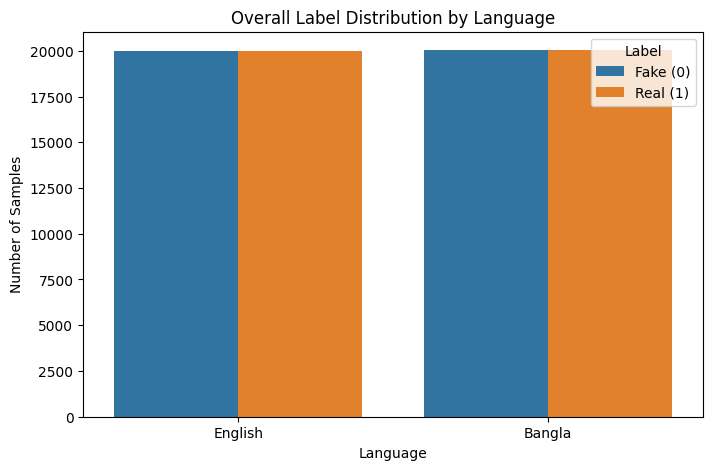

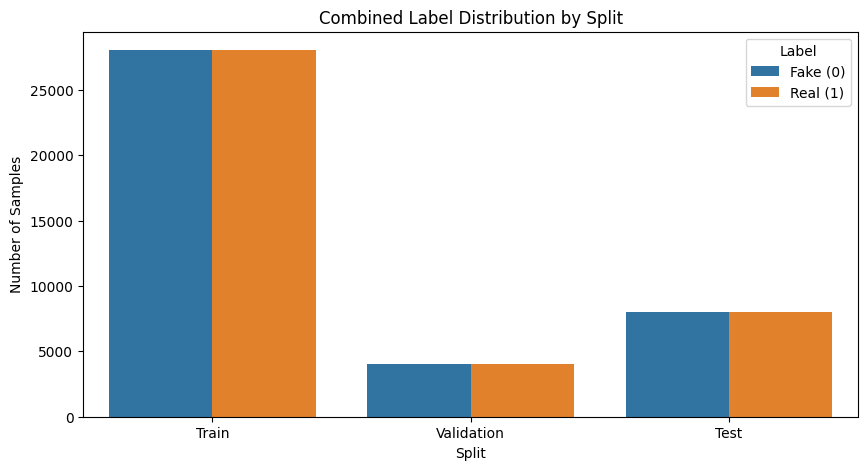

In [11]:
# Step 11: Label Distribution Visualization

label_distribution = pd.concat([
    english_train.assign(Language="English", Split="Train"),
    english_validation.assign(Language="English", Split="Validation"),
    english_test.assign(Language="English", Split="Test"),
    bangla_train.assign(Language="Bangla", Split="Train"),
    bangla_validation.assign(Language="Bangla", Split="Validation"),
    bangla_test.assign(Language="Bangla", Split="Test")
], ignore_index=True)

plt.figure(figsize=(8, 5))
sns.countplot(data=label_distribution, x="Language", hue="label")
plt.title("Overall Label Distribution by Language")
plt.xlabel("Language")
plt.ylabel("Number of Samples")
plt.legend(title="Label", labels=["Fake (0)", "Real (1)"])
plt.show()

plt.figure(figsize=(10, 5))
sns.countplot(data=label_distribution, x="Split", hue="label")
plt.title("Combined Label Distribution by Split")
plt.xlabel("Split")
plt.ylabel("Number of Samples")
plt.legend(title="Label", labels=["Fake (0)", "Real (1)"])
plt.show()


## Dataset Quality Control Verification

The final datasets were cleaned before upload. This section verifies that the uploaded files are still safe to use. The checks include missing values, invalid labels, empty text, duplicate text, and cross-split overlap.


In [12]:
# Step 12: Missing Value and Invalid Label Check

def quality_check_basic(df, name):
    return {
        "Dataset": name,
        "Rows": df.shape[0],
        "Missing Text": df["text"].isna().sum(),
        "Missing Label": df["label"].isna().sum(),
        "Empty Text": (df["text"].astype(str).str.strip() == "").sum(),
        "Invalid Labels": (~df["label"].isin([0, 1])).sum(),
        "Exact Duplicate Texts": df["text"].duplicated().sum()
    }

quality_table = pd.DataFrame([
    quality_check_basic(english_train, "English Train"),
    quality_check_basic(english_validation, "English Validation"),
    quality_check_basic(english_test, "English Test"),
    quality_check_basic(bangla_train, "Bangla Train"),
    quality_check_basic(bangla_validation, "Bangla Validation"),
    quality_check_basic(bangla_test, "Bangla Test")
])

display(quality_table)


,Dataset,Rows,Missing Text,Missing Label,Empty Text,Invalid Labels,Exact Duplicate Texts
0,English Train,28016,0,0,0,0,0
1,English Validation,4002,0,0,0,0,0
2,English Test,8004,0,0,0,0,0
3,Bangla Train,28054,0,0,0,0,0
4,Bangla Validation,4008,0,0,0,0,0
5,Bangla Test,8016,0,0,0,0,0


In [13]:
# Step 13: Cross-Split Exact Overlap Check

def overlap_count(df1, df2):
    return len(set(df1["text"].astype(str)) & set(df2["text"].astype(str)))

overlap_table = pd.DataFrame({
    "Language": ["English", "English", "English", "Bangla", "Bangla", "Bangla"],
    "Comparison": [
        "Train vs Validation", "Train vs Test", "Validation vs Test",
        "Train vs Validation", "Train vs Test", "Validation vs Test"
    ],
    "Exact Text Overlap": [
        overlap_count(english_train, english_validation),
        overlap_count(english_train, english_test),
        overlap_count(english_validation, english_test),
        overlap_count(bangla_train, bangla_validation),
        overlap_count(bangla_train, bangla_test),
        overlap_count(bangla_validation, bangla_test)
    ]
})

display(overlap_table)


,Language,Comparison,Exact Text Overlap
0,English,Train vs Validation,0
1,English,Train vs Test,0
2,English,Validation vs Test,0
3,Bangla,Train vs Validation,0
4,Bangla,Train vs Test,0
5,Bangla,Validation vs Test,0


In [14]:
# Step 13A: Cross-Split Normalized Overlap Check

def normalize_for_overlap(text):
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

def normalized_overlap_count(df1, df2):
    set1 = set(df1["text"].astype(str).apply(normalize_for_overlap))
    set2 = set(df2["text"].astype(str).apply(normalize_for_overlap))
    return len(set1 & set2)

normalized_overlap_table = pd.DataFrame({
    "Language": ["English", "English", "English", "Bangla", "Bangla", "Bangla"],
    "Comparison": [
        "Train vs Validation", "Train vs Test", "Validation vs Test",
        "Train vs Validation", "Train vs Test", "Validation vs Test"
    ],
    "Normalized Text Overlap": [
        normalized_overlap_count(english_train, english_validation),
        normalized_overlap_count(english_train, english_test),
        normalized_overlap_count(english_validation, english_test),
        normalized_overlap_count(bangla_train, bangla_validation),
        normalized_overlap_count(bangla_train, bangla_test),
        normalized_overlap_count(bangla_validation, bangla_test)
    ]
})

display(normalized_overlap_table)

,Language,Comparison,Normalized Text Overlap
0,English,Train vs Validation,0
1,English,Train vs Test,0
2,English,Validation vs Test,0
3,Bangla,Train vs Validation,0
4,Bangla,Train vs Test,0
5,Bangla,Validation vs Test,0


In [15]:
# Step 14: Word Count Analysis

for df in all_datasets:
    df["word_count"] = df["text"].astype(str).apply(lambda x: len(x.split()))

word_count_summary = pd.DataFrame({
    "Dataset": [
        "English Train", "English Validation", "English Test",
        "Bangla Train", "Bangla Validation", "Bangla Test"
    ],
    "Minimum Words": [
        english_train["word_count"].min(), english_validation["word_count"].min(), english_test["word_count"].min(),
        bangla_train["word_count"].min(), bangla_validation["word_count"].min(), bangla_test["word_count"].min()
    ],
    "Mean Words": [
        round(english_train["word_count"].mean(), 2), round(english_validation["word_count"].mean(), 2), round(english_test["word_count"].mean(), 2),
        round(bangla_train["word_count"].mean(), 2), round(bangla_validation["word_count"].mean(), 2), round(bangla_test["word_count"].mean(), 2)
    ],
    "Median Words": [
        english_train["word_count"].median(), english_validation["word_count"].median(), english_test["word_count"].median(),
        bangla_train["word_count"].median(), bangla_validation["word_count"].median(), bangla_test["word_count"].median()
    ]
})

display(word_count_summary)


,Dataset,Minimum Words,Mean Words,Median Words
0,English Train,22,319.88,229.0
1,English Validation,22,314.83,225.0
2,English Test,22,318.79,227.0
3,Bangla Train,30,272.35,218.0
4,Bangla Validation,32,272.63,219.0
5,Bangla Test,30,273.39,218.0


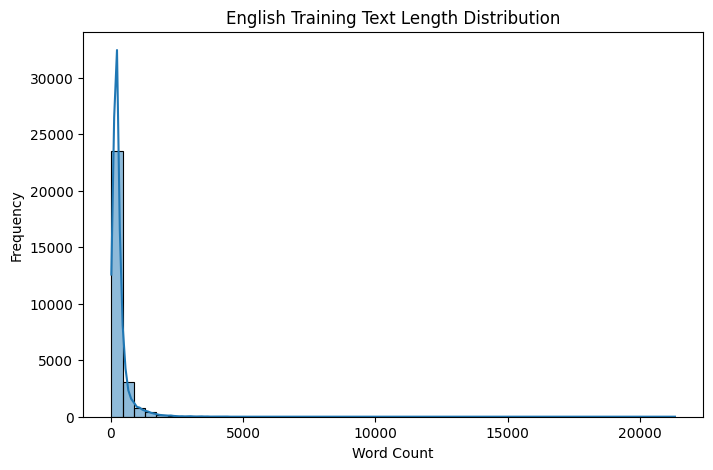

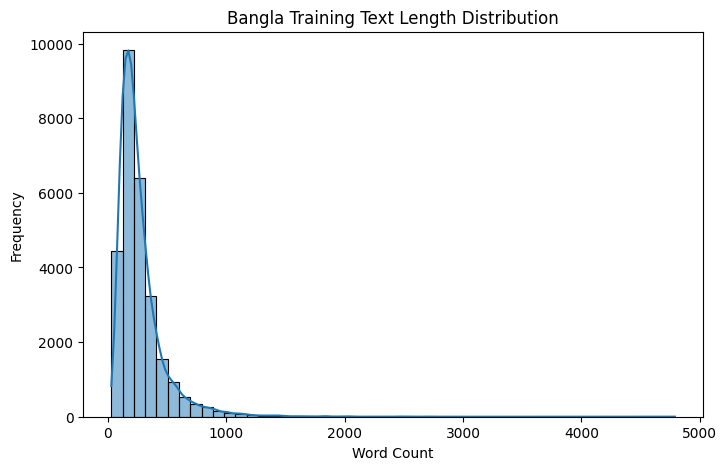

In [16]:
# Step 15: Text Length Visualization

plt.figure(figsize=(8, 5))
sns.histplot(english_train["word_count"], bins=50, kde=True)
plt.title("English Training Text Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(bangla_train["word_count"], bins=50, kde=True)
plt.title("Bangla Training Text Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()


## Final Text Preparation

The uploaded datasets are already cleaned. Therefore, this notebook applies only light final text preparation. This avoids damaging meaningful linguistic patterns, especially in Bangla. The same label mapping is preserved for both datasets.


In [17]:
# Step 16: Light Final Text Preparation Function

def final_text_prepare(text):
    text = str(text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

for df in all_datasets:
    df["clean_text"] = df["text"].apply(final_text_prepare)

print("Final text preparation completed.")


Final text preparation completed.


In [18]:
# Step 17: Assign Train, Validation, and Test Variables

X_eng_train = english_train["clean_text"]
y_eng_train = english_train["label"]
X_eng_val = english_validation["clean_text"]
y_eng_val = english_validation["label"]
X_eng_test = english_test["clean_text"]
y_eng_test = english_test["label"]

X_ban_train = bangla_train["clean_text"]
y_ban_train = bangla_train["label"]
X_ban_val = bangla_validation["clean_text"]
y_ban_val = bangla_validation["label"]
X_ban_test = bangla_test["clean_text"]
y_ban_test = bangla_test["label"]

print("English Train:", X_eng_train.shape, y_eng_train.shape)
print("English Validation:", X_eng_val.shape, y_eng_val.shape)
print("English Test:", X_eng_test.shape, y_eng_test.shape)

print("\nBangla Train:", X_ban_train.shape, y_ban_train.shape)
print("Bangla Validation:", X_ban_val.shape, y_ban_val.shape)
print("Bangla Test:", X_ban_test.shape, y_ban_test.shape)


English Train: (28016,) (28016,)
English Validation: (4002,) (4002,)
English Test: (8004,) (8004,)

Bangla Train: (28054,) (28054,)
Bangla Validation: (4008,) (4008,)
Bangla Test: (8016,) (8016,)


## TF-IDF Feature Extraction

TF-IDF converts text into numerical feature vectors. To prevent data leakage, the TF-IDF vectorizer is fitted only on the training set. The validation and test sets are transformed using the vectorizer fitted on the training data.

Separate TF-IDF vectorizers are used for English and Bangla because the languages have different scripts and vocabulary distributions.


In [19]:
# Step 18: Create TF-IDF Vectorizers

TFIDF_MAX_FEATURES = 20000

english_tfidf = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    lowercase=True
)

bangla_tfidf = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    lowercase=False
)

print("TF-IDF vectorizers created successfully.")


TF-IDF vectorizers created successfully.


In [20]:
# Step 19: Fit TF-IDF on Training Data and Transform Validation/Test Data

X_eng_train_tfidf = english_tfidf.fit_transform(X_eng_train)
X_eng_val_tfidf = english_tfidf.transform(X_eng_val)
X_eng_test_tfidf = english_tfidf.transform(X_eng_test)

X_ban_train_tfidf = bangla_tfidf.fit_transform(X_ban_train)
X_ban_val_tfidf = bangla_tfidf.transform(X_ban_val)
X_ban_test_tfidf = bangla_tfidf.transform(X_ban_test)

print("English TF-IDF Shapes:")
print("Train:", X_eng_train_tfidf.shape)
print("Validation:", X_eng_val_tfidf.shape)
print("Test:", X_eng_test_tfidf.shape)

print("\nBangla TF-IDF Shapes:")
print("Train:", X_ban_train_tfidf.shape)
print("Validation:", X_ban_val_tfidf.shape)
print("Test:", X_ban_test_tfidf.shape)


English TF-IDF Shapes:
Train: (28016, 20000)
Validation: (4002, 20000)
Test: (8004, 20000)

Bangla TF-IDF Shapes:
Train: (28054, 20000)
Validation: (4008, 20000)
Test: (8016, 20000)


In [21]:
# Step 20: TF-IDF Settings Table

tfidf_settings = pd.DataFrame({
    "Parameter": ["max_features", "ngram_range", "min_df", "max_df", "sublinear_tf"],
    "English Value": [TFIDF_MAX_FEATURES, "(1, 2)", 2, 0.95, True],
    "Bangla Value": [TFIDF_MAX_FEATURES, "(1, 2)", 2, 0.95, True]
})

display(tfidf_settings)


,Parameter,English Value,Bangla Value
0,max_features,20000,20000
1,ngram_range,"(1, 2)","(1, 2)"
2,min_df,2,2
3,max_df,0.95,0.95
4,sublinear_tf,True,True


## System Architecture Diagram

The following diagram presents the overall workflow of the proposed fake news detection system. The pipeline starts with cleaned Bangla and English text datasets, followed by language-specific text preparation, TF-IDF feature extraction, classical machine learning model training, and final performance evaluation.

This visual representation helps summarize the experimental design and shows how the Bangla and English fake news detection pipelines are processed separately but evaluated under the same methodological framework.

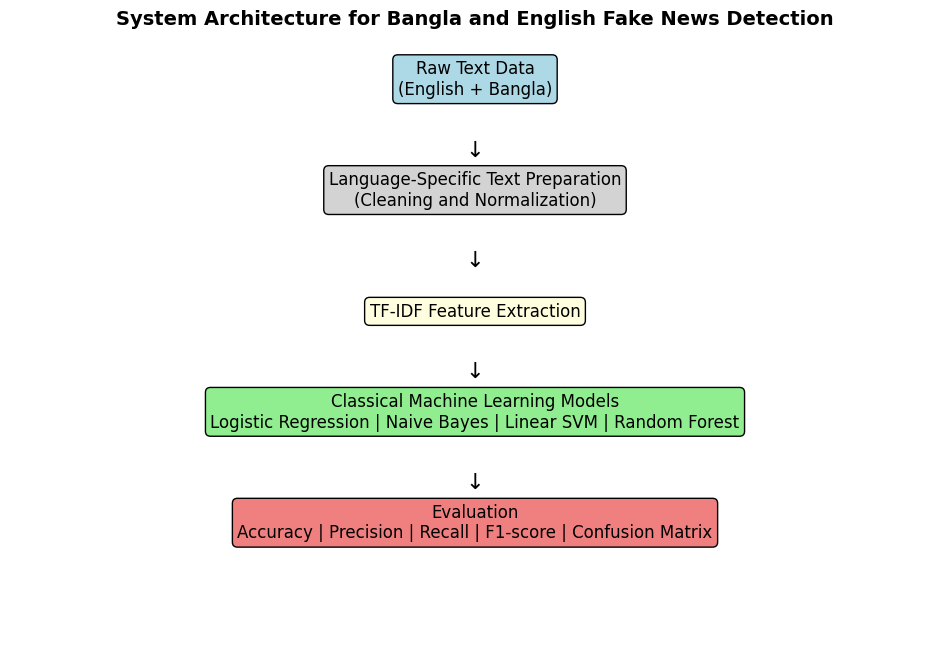

In [22]:
# Step 21: System Architecture Diagram

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# Box 1
plt.text(
    0.5, 0.90,
    "Raw Text Data\n(English + Bangla)",
    ha="center",
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="lightblue")
)

# Arrow
plt.text(0.5, 0.80, "↓", ha="center", fontsize=16)

# Box 2
plt.text(
    0.5, 0.72,
    "Language-Specific Text Preparation\n(Cleaning and Normalization)",
    ha="center",
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="lightgray")
)

# Arrow
plt.text(0.5, 0.62, "↓", ha="center", fontsize=16)

# Box 3
plt.text(
    0.5, 0.54,
    "TF-IDF Feature Extraction",
    ha="center",
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="lightyellow")
)

# Arrow
plt.text(0.5, 0.44, "↓", ha="center", fontsize=16)

# Box 4
plt.text(
    0.5, 0.36,
    "Classical Machine Learning Models\nLogistic Regression | Naive Bayes | Linear SVM | Random Forest",
    ha="center",
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="lightgreen")
)

# Arrow
plt.text(0.5, 0.26, "↓", ha="center", fontsize=16)

# Box 5
plt.text(
    0.5, 0.18,
    "Evaluation\nAccuracy | Precision | Recall | F1-score | Confusion Matrix",
    ha="center",
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="lightcoral")
)

plt.axis("off")
plt.title(
    "System Architecture for Bangla and English Fake News Detection",
    fontsize=14,
    fontweight="bold"
)

plt.show()

## Hyperparameter Tuning and Cross-Validation

To improve model reliability, Linear SVM was tuned using different values of the regularization parameter C. The best parameter was selected based on weighted F1-score. After selecting the best C value, 5-fold cross-validation was performed on the training data to examine model stability.

In [23]:
# Step 22: Hyperparameter Tuning for Linear SVM

from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

# Parameter grid for Linear SVM
svm_params = {
    'C': [0.1, 1, 10]
}

# English SVM tuning
svm_grid_english = GridSearchCV(
    LinearSVC(class_weight='balanced', max_iter=10000),
    svm_params,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1
)

svm_grid_english.fit(X_eng_train_tfidf, y_eng_train)

print("Best English SVM Parameters:", svm_grid_english.best_params_)
print("Best English SVM Validation Score:", svm_grid_english.best_score_)


# Bangla SVM tuning
svm_grid_bangla = GridSearchCV(
    LinearSVC(class_weight='balanced', max_iter=10000),
    svm_params,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1
)

svm_grid_bangla.fit(X_ban_train_tfidf, y_ban_train)

print("\nBest Bangla SVM Parameters:", svm_grid_bangla.best_params_)
print("Best Bangla SVM Validation Score:", svm_grid_bangla.best_score_)

Best English SVM Parameters: {'C': 1}
Best English SVM Validation Score: 0.979475837443831

Best Bangla SVM Parameters: {'C': 0.1}
Best Bangla SVM Validation Score: 0.8032929127620884


In [24]:
# Step 23: Best Hyperparameter Summary

best_hyperparameters = pd.DataFrame({
    "Language": ["English", "Bangla"],
    "Model": ["Linear SVM", "Linear SVM"],
    "Best Parameters": [
        svm_grid_english.best_params_,
        svm_grid_bangla.best_params_
    ],
    "Best CV F1-score": [
        svm_grid_english.best_score_,
        svm_grid_bangla.best_score_
    ]
})

display(best_hyperparameters)

,Language,Model,Best Parameters,Best CV F1-score
0,English,Linear SVM,{'C': 1},0.979476
1,Bangla,Linear SVM,{'C': 0.1},0.803293


In [25]:
# Step 24: Cross Validation for Linear SVM

from sklearn.model_selection import cross_val_score

# Extract best C values
best_c_english = svm_grid_english.best_params_['C']
best_c_bangla = svm_grid_bangla.best_params_['C']

# English cross-validation
english_svm_cv = LinearSVC(
    class_weight='balanced',
    C=best_c_english,
    max_iter=10000
)

english_cv_scores = cross_val_score(
    english_svm_cv,
    X_eng_train_tfidf,
    y_eng_train,
    cv=5,
    scoring='f1_weighted'
)

print("English 5-Fold CV F1 Scores:", english_cv_scores)
print("English Mean CV F1 Score:", english_cv_scores.mean())


# Bangla cross-validation
bangla_svm_cv = LinearSVC(
    class_weight='balanced',
    C=best_c_bangla,
    max_iter=10000
)

bangla_cv_scores = cross_val_score(
    bangla_svm_cv,
    X_ban_train_tfidf,
    y_ban_train,
    cv=5,
    scoring='f1_weighted'
)

print("\nBangla 5-Fold CV F1 Scores:", bangla_cv_scores)
print("Bangla Mean CV F1 Score:", bangla_cv_scores.mean())

English 5-Fold CV F1 Scores: [0.98108485 0.98233086 0.97893984 0.98215185 0.97893982]
English Mean CV F1 Score: 0.9806894451854037

Bangla 5-Fold CV F1 Scores: [0.80479225 0.80769707 0.80146142 0.8097627  0.80604394]
Bangla Mean CV F1 Score: 0.8059514760580093


In [26]:
# Step 25: Cross-Validation Summary Table

cv_summary = pd.DataFrame({
    "Language": ["English", "Bangla"],
    "Model": ["Linear SVM", "Linear SVM"],
    "Best C": [best_c_english, best_c_bangla],
    "CV Fold 1": [english_cv_scores[0], bangla_cv_scores[0]],
    "CV Fold 2": [english_cv_scores[1], bangla_cv_scores[1]],
    "CV Fold 3": [english_cv_scores[2], bangla_cv_scores[2]],
    "CV Fold 4": [english_cv_scores[3], bangla_cv_scores[3]],
    "CV Fold 5": [english_cv_scores[4], bangla_cv_scores[4]],
    "Mean CV F1-score": [english_cv_scores.mean(), bangla_cv_scores.mean()],
    "Std CV F1-score": [english_cv_scores.std(), bangla_cv_scores.std()]
})

display(cv_summary)

,Language,Model,Best C,CV Fold 1,CV Fold 2,CV Fold 3,CV Fold 4,CV Fold 5,Mean CV F1-score,Std CV F1-score
0,English,Linear SVM,1.0,0.981085,0.982331,0.978940,0.982152,0.978940,0.980689,0.001491
1,Bangla,Linear SVM,0.1,0.804792,0.807697,0.801461,0.809763,0.806044,0.805951,0.002796


## Model Training and Evaluation

Four classical machine learning models are evaluated:

1. Logistic Regression
2. Multinomial Naive Bayes
3. Linear Support Vector Machine
4. Random Forest

Validation performance is used for model comparison and selection. The test set is used only for final evaluation.


In [27]:
# Step 26: Define Evaluation Function

def get_auc_score(model, X, y_true):
    """Calculate ROC-AUC when possible."""
    try:
        if hasattr(model, "predict_proba"):
            scores = model.predict_proba(X)[:, 1]
        elif hasattr(model, "decision_function"):
            scores = model.decision_function(X)
        else:
            return np.nan
        return roc_auc_score(y_true, scores)
    except Exception:
        return np.nan


def evaluate_predictions(y_true, y_pred, model=None, X=None):
    result = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1-score": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "Macro-F1": f1_score(y_true, y_pred, average="macro", zero_division=0)
    }
    if model is not None and X is not None:
        result["ROC-AUC"] = get_auc_score(model, X, y_true)
    else:
        result["ROC-AUC"] = np.nan
    return result

print("Evaluation functions ready.")


Evaluation functions ready.


In [28]:
# Step 27: Define Model Training Function

def train_validate_test_model(model, X_train, y_train, X_val, y_val, X_test, y_test, model_name, language):
    model.fit(X_train, y_train)

    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)

    val_metrics = evaluate_predictions(y_val, y_val_pred, model=model, X=X_val)
    test_metrics = evaluate_predictions(y_test, y_test_pred, model=model, X=X_test)

    val_result = {
        "Language": language,
        "Model": model_name,
        "Validation Accuracy": val_metrics["Accuracy"],
        "Validation Precision": val_metrics["Precision"],
        "Validation Recall": val_metrics["Recall"],
        "Validation F1-score": val_metrics["F1-score"],
        "Validation Macro-F1": val_metrics["Macro-F1"],
        "Validation ROC-AUC": val_metrics["ROC-AUC"]
    }

    test_result = {
        "Language": language,
        "Model": model_name,
        "Accuracy": test_metrics["Accuracy"],
        "Precision": test_metrics["Precision"],
        "Recall": test_metrics["Recall"],
        "F1-score": test_metrics["F1-score"],
        "Macro-F1": test_metrics["Macro-F1"],
        "ROC-AUC": test_metrics["ROC-AUC"]
    }

    print(f"Completed: {language} - {model_name}")
    print(classification_report(y_test, y_test_pred, target_names=["Fake News", "Real News"], zero_division=0))

    return val_result, test_result, y_test_pred, model


In [29]:
# Step 28: Define Machine Learning Models

english_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(C=best_c_english, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=None, random_state=RANDOM_STATE, class_weight="balanced", n_jobs=-1)
}

bangla_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(C=best_c_bangla, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=None, random_state=RANDOM_STATE, class_weight="balanced", n_jobs=-1)
}

print("English Models:", list(english_models.keys()))
print("Bangla Models:", list(bangla_models.keys()))


English Models: ['Logistic Regression', 'Naive Bayes', 'Linear SVM', 'Random Forest']
Bangla Models: ['Logistic Regression', 'Naive Bayes', 'Linear SVM', 'Random Forest']


In [30]:
# Step 29: Train and Evaluate English Models

english_validation_results = []
english_test_results = []
english_test_predictions = {}
english_trained_models = {}

for model_name, model in english_models.items():
    val_result, test_result, y_pred, trained_model = train_validate_test_model(
        model=model,
        X_train=X_eng_train_tfidf,
        y_train=y_eng_train,
        X_val=X_eng_val_tfidf,
        y_val=y_eng_val,
        X_test=X_eng_test_tfidf,
        y_test=y_eng_test,
        model_name=model_name,
        language="English"
    )

    english_validation_results.append(val_result)
    english_test_results.append(test_result)
    english_test_predictions[model_name] = y_pred
    english_trained_models[model_name] = trained_model


Completed: English - Logistic Regression
              precision    recall  f1-score   support

   Fake News       0.98      0.97      0.98      4002
   Real News       0.97      0.98      0.98      4002

    accuracy                           0.98      8004
   macro avg       0.98      0.98      0.98      8004
weighted avg       0.98      0.98      0.98      8004

Completed: English - Naive Bayes
              precision    recall  f1-score   support

   Fake News       0.93      0.94      0.94      4002
   Real News       0.94      0.93      0.94      4002

    accuracy                           0.94      8004
   macro avg       0.94      0.94      0.94      8004
weighted avg       0.94      0.94      0.94      8004

Completed: English - Linear SVM
              precision    recall  f1-score   support

   Fake News       0.99      0.98      0.98      4002
   Real News       0.98      0.99      0.98      4002

    accuracy                           0.98      8004
   macro avg       0.9

In [31]:
# Step 30: Train and Evaluate Bangla Models

bangla_validation_results = []
bangla_test_results = []
bangla_test_predictions = {}
bangla_trained_models = {}

for model_name, model in bangla_models.items():
    val_result, test_result, y_pred, trained_model = train_validate_test_model(
        model=model,
        X_train=X_ban_train_tfidf,
        y_train=y_ban_train,
        X_val=X_ban_val_tfidf,
        y_val=y_ban_val,
        X_test=X_ban_test_tfidf,
        y_test=y_ban_test,
        model_name=model_name,
        language="Bangla"
    )

    bangla_validation_results.append(val_result)
    bangla_test_results.append(test_result)
    bangla_test_predictions[model_name] = y_pred
    bangla_trained_models[model_name] = trained_model


Completed: Bangla - Logistic Regression
              precision    recall  f1-score   support

   Fake News       0.81      0.82      0.82      4008
   Real News       0.82      0.80      0.81      4008

    accuracy                           0.81      8016
   macro avg       0.81      0.81      0.81      8016
weighted avg       0.81      0.81      0.81      8016

Completed: Bangla - Naive Bayes
              precision    recall  f1-score   support

   Fake News       0.76      0.76      0.76      4008
   Real News       0.76      0.76      0.76      4008

    accuracy                           0.76      8016
   macro avg       0.76      0.76      0.76      8016
weighted avg       0.76      0.76      0.76      8016

Completed: Bangla - Linear SVM
              precision    recall  f1-score   support

   Fake News       0.81      0.83      0.82      4008
   Real News       0.82      0.80      0.81      4008

    accuracy                           0.82      8016
   macro avg       0.82  

In [32]:
# Step 31: Validation Result Table

english_validation_df = pd.DataFrame(english_validation_results)
bangla_validation_df = pd.DataFrame(bangla_validation_results)
validation_results_df = pd.concat([english_validation_df, bangla_validation_df], ignore_index=True)
validation_results_df = validation_results_df.round(4)

display(validation_results_df)


,Language,Model,Validation Accuracy,Validation Precision,Validation Recall,Validation F1-score,Validation Macro-F1,Validation ROC-AUC
0,English,Logistic Regression,0.9725,0.9725,0.9725,0.9725,0.9725,0.9966
1,English,Naive Bayes,0.9308,0.9312,0.9308,0.9308,0.9308,0.9821
2,English,Linear SVM,0.9818,0.9818,0.9818,0.9818,0.9818,0.9981
3,English,Random Forest,0.9655,0.9655,0.9655,0.9655,0.9655,0.9944
4,Bangla,Logistic Regression,0.8211,0.8212,0.8211,0.8211,0.8211,0.9000
5,Bangla,Naive Bayes,0.7537,0.7538,0.7537,0.7537,0.7537,0.8308
6,Bangla,Linear SVM,0.8221,0.8222,0.8221,0.8221,0.8221,0.8997
7,Bangla,Random Forest,0.7917,0.7921,0.7917,0.7916,0.7916,0.8743


In [33]:
# Step 32: Best Model Based on Validation F1-score

best_english_validation = validation_results_df[
    validation_results_df["Language"] == "English"
].sort_values(by="Validation F1-score", ascending=False).iloc[0]

best_bangla_validation = validation_results_df[
    validation_results_df["Language"] == "Bangla"
].sort_values(by="Validation F1-score", ascending=False).iloc[0]

print("Best English Model Based on Validation F1-score:")
print(best_english_validation)

print("\nBest Bangla Model Based on Validation F1-score:")
print(best_bangla_validation)


Best English Model Based on Validation F1-score:
Language                   English
Model                   Linear SVM
Validation Accuracy         0.9818
Validation Precision        0.9818
Validation Recall           0.9818
Validation F1-score         0.9818
Validation Macro-F1         0.9818
Validation ROC-AUC          0.9981
Name: 2, dtype: object

Best Bangla Model Based on Validation F1-score:
Language                    Bangla
Model                   Linear SVM
Validation Accuracy         0.8221
Validation Precision        0.8222
Validation Recall           0.8221
Validation F1-score         0.8221
Validation Macro-F1         0.8221
Validation ROC-AUC          0.8997
Name: 6, dtype: object


In [34]:
# Step 33: Final Test Result Table

english_results_df = pd.DataFrame(english_test_results)
bangla_results_df = pd.DataFrame(bangla_test_results)

final_results_df = pd.concat([english_results_df, bangla_results_df], ignore_index=True)
final_results_df = final_results_df.round(4)

display(final_results_df)


,Language,Model,Accuracy,Precision,Recall,F1-score,Macro-F1,ROC-AUC
0,English,Logistic Regression,0.9759,0.9759,0.9759,0.9759,0.9759,0.9971
1,English,Naive Bayes,0.9368,0.9368,0.9368,0.9368,0.9368,0.9830
2,English,Linear SVM,0.9833,0.9833,0.9833,0.9833,0.9833,0.9984
3,English,Random Forest,0.9645,0.9645,0.9645,0.9645,0.9645,0.9954
4,Bangla,Logistic Regression,0.8132,0.8134,0.8132,0.8132,0.8132,0.8977
5,Bangla,Naive Bayes,0.7576,0.7576,0.7576,0.7576,0.7576,0.8321
6,Bangla,Linear SVM,0.8155,0.8157,0.8155,0.8155,0.8155,0.8979
7,Bangla,Random Forest,0.7923,0.7930,0.7923,0.7922,0.7922,0.8732


## Validation-Test Consistency Note

The validation and final test performances were compared to assess whether the selected models showed signs of overfitting. Similar validation and test scores suggest that the models generalized consistently across the held-out test sets. Large differences between validation and test results would indicate possible overfitting or dataset distribution differences.

## Final Model Summary

The following summary table presents the final test performance of all evaluated models for both English and Bangla datasets. The table compares key evaluation metrics, including accuracy, F1-score, macro-F1, and ROC-AUC, across languages and models. This format helps identify overall performance differences between classifiers and supports model comparison for the final discussion.

In [35]:
# Step 34: Final Summary Table

summary_table = final_results_df.pivot(
    index="Model",
    columns="Language",
    values=["Accuracy", "F1-score", "Macro-F1", "ROC-AUC"]
)

display(summary_table)

Accuracy         F1-score         Macro-F1          \
Language              Bangla English   Bangla English   Bangla English   
Model                                                                    
Linear SVM            0.8155  0.9833   0.8155  0.9833   0.8155  0.9833   
Logistic Regression   0.8132  0.9759   0.8132  0.9759   0.8132  0.9759   
Naive Bayes           0.7576  0.9368   0.7576  0.9368   0.7576  0.9368   
Random Forest         0.7923  0.9645   0.7922  0.9645   0.7922  0.9645   

                    ROC-AUC          
Language             Bangla English  
Model                                
Linear SVM           0.8979  0.9984  
Logistic Regression  0.8977  0.9971  
Naive Bayes          0.8321  0.9830  
Random Forest        0.8732  0.9954

In [36]:
# Step 35: Final Test Results for Validation-Selected Models

best_english_validation_model = best_english_validation["Model"]
best_bangla_validation_model = best_bangla_validation["Model"]

best_english_test = final_results_df[
    (final_results_df["Language"] == "English") &
    (final_results_df["Model"] == best_english_validation_model)
].iloc[0]

best_bangla_test = final_results_df[
    (final_results_df["Language"] == "Bangla") &
    (final_results_df["Model"] == best_bangla_validation_model)
].iloc[0]

print("Final English Test Result for Validation-Selected Model:")
print(best_english_test)

print("\nFinal Bangla Test Result for Validation-Selected Model:")
print(best_bangla_test)

Final English Test Result for Validation-Selected Model:
Language        English
Model        Linear SVM
Accuracy         0.9833
Precision        0.9833
Recall           0.9833
F1-score         0.9833
Macro-F1         0.9833
ROC-AUC          0.9984
Name: 2, dtype: object

Final Bangla Test Result for Validation-Selected Model:
Language         Bangla
Model        Linear SVM
Accuracy         0.8155
Precision        0.8157
Recall           0.8155
F1-score         0.8155
Macro-F1         0.8155
ROC-AUC          0.8979
Name: 6, dtype: object


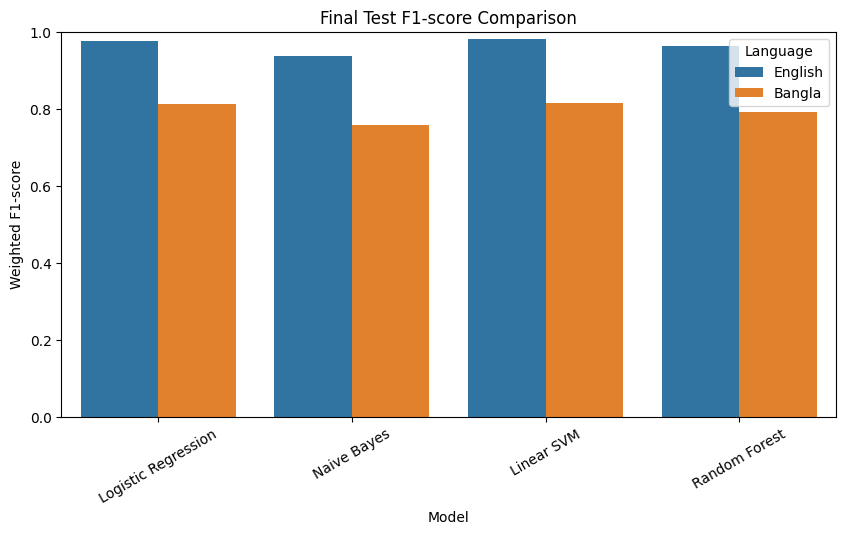

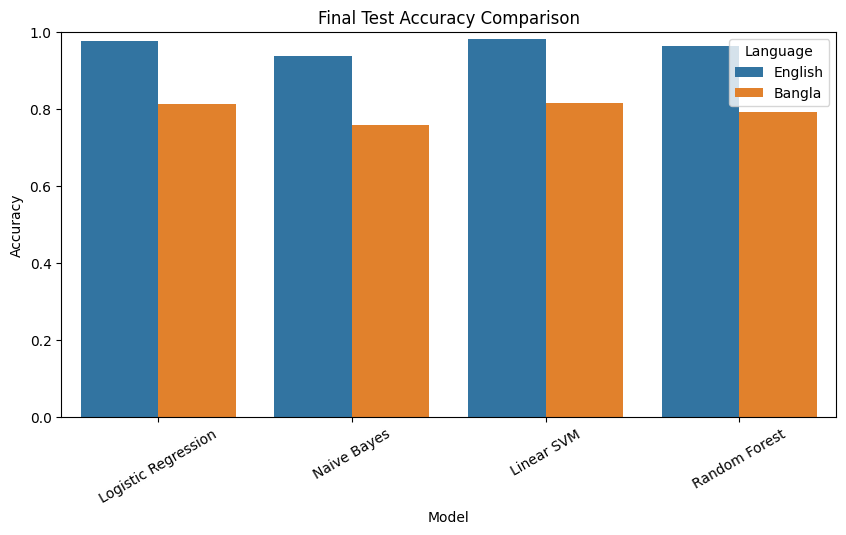

In [37]:
# Step 36: Model Performance Visualization

plt.figure(figsize=(10, 5))
sns.barplot(data=final_results_df, x="Model", y="F1-score", hue="Language")
plt.title("Final Test F1-score Comparison")
plt.xlabel("Model")
plt.ylabel("Weighted F1-score")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=final_results_df, x="Model", y="Accuracy", hue="Language")
plt.title("Final Test Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.show()


## Confusion Matrix Analysis

Confusion matrices show how many fake and real news samples were correctly or incorrectly classified. This is important because accuracy alone does not explain the type of classification error.


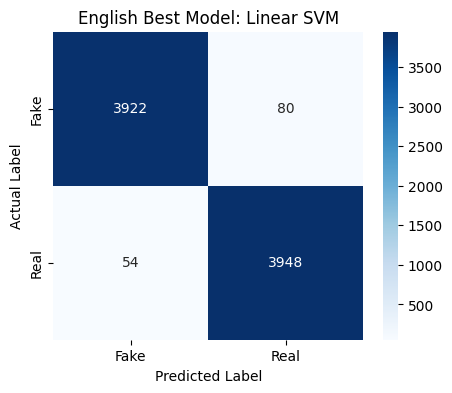

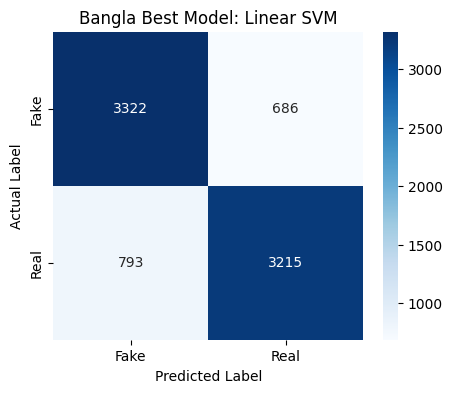

In [38]:
# Step 37: Confusion Matrix Function

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Fake", "Real"],
        yticklabels=["Fake", "Real"]
    )
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.show()
    return cm

best_english_model_name = best_english_test["Model"]
best_bangla_model_name = best_bangla_test["Model"]

english_best_predictions = english_test_predictions[best_english_model_name]
bangla_best_predictions = bangla_test_predictions[best_bangla_model_name]

english_cm = plot_confusion_matrix(y_eng_test, english_best_predictions, f"English Best Model: {best_english_model_name}")
bangla_cm = plot_confusion_matrix(y_ban_test, bangla_best_predictions, f"Bangla Best Model: {best_bangla_model_name}")


In [39]:
# Step 38: Confusion Matrix Values Table

confusion_summary = pd.DataFrame({
    "Language": ["English", "Bangla"],
    "Best Model": [best_english_model_name, best_bangla_model_name],
    "True Fake Predicted Fake": [english_cm[0, 0], bangla_cm[0, 0]],
    "True Fake Predicted Real": [english_cm[0, 1], bangla_cm[0, 1]],
    "True Real Predicted Fake": [english_cm[1, 0], bangla_cm[1, 0]],
    "True Real Predicted Real": [english_cm[1, 1], bangla_cm[1, 1]]
})

display(confusion_summary)


,Language,Best Model,True Fake Predicted Fake,True Fake Predicted Real,True Real Predicted Fake,True Real Predicted Real
0,English,Linear SVM,3922,80,54,3948
1,Bangla,Linear SVM,3322,686,793,3215


## Confusion Matrices for All Models

In addition to the best-model confusion matrices, confusion matrices for all evaluated models are shown to provide a more complete comparison of classification behavior across algorithms.

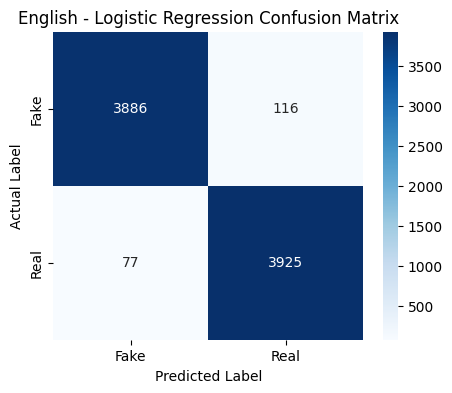

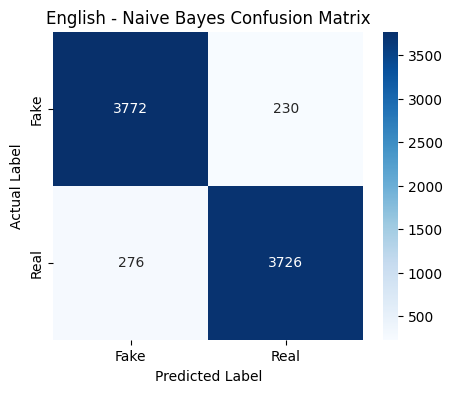

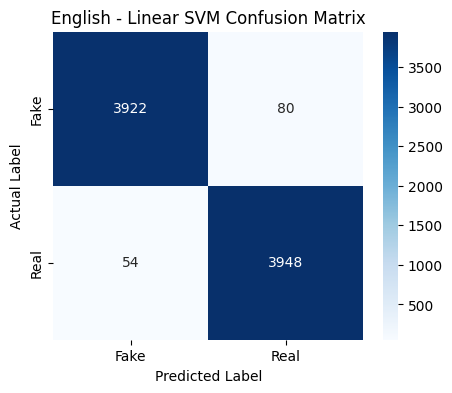

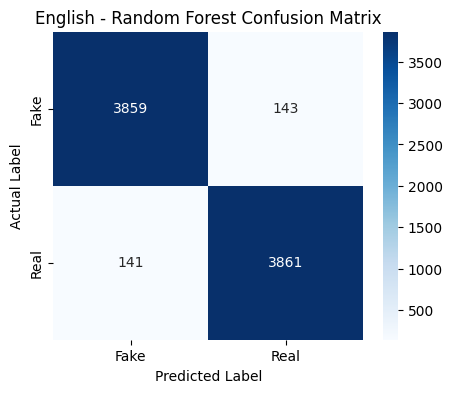

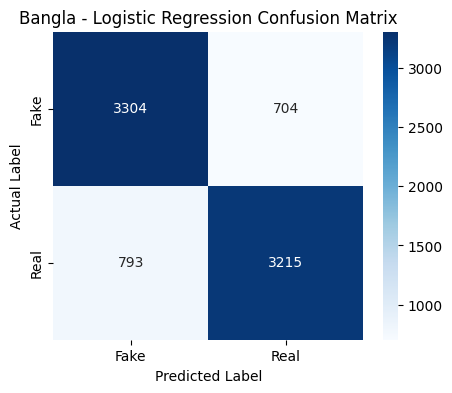

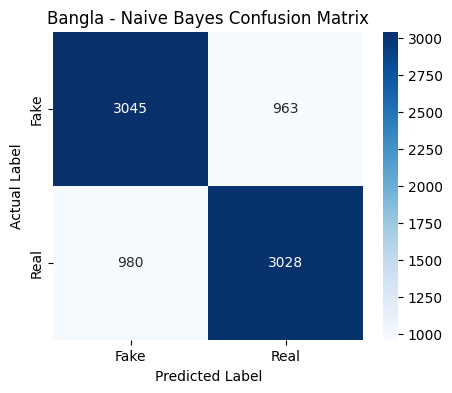

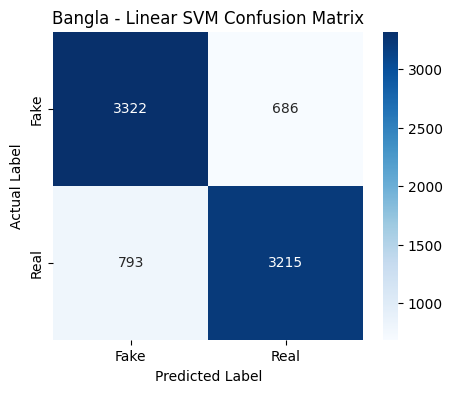

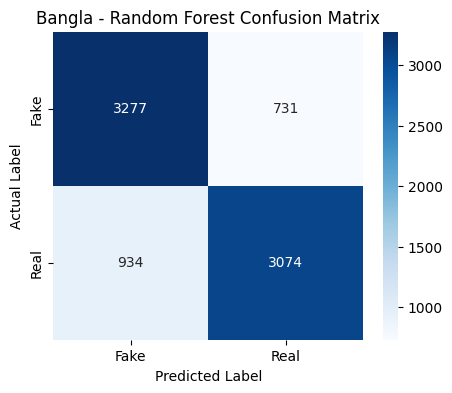

In [40]:
# Step 38A: Confusion Matrices for All Models

def plot_all_confusion_matrices(y_true, predictions_dict, language):
    for model_name, y_pred in predictions_dict.items():
        cm = confusion_matrix(y_true, y_pred)

        plt.figure(figsize=(5, 4))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Fake", "Real"],
            yticklabels=["Fake", "Real"]
        )
        plt.title(f"{language} - {model_name} Confusion Matrix")
        plt.xlabel("Predicted Label")
        plt.ylabel("Actual Label")
        plt.show()


plot_all_confusion_matrices(
    y_true=y_eng_test,
    predictions_dict=english_test_predictions,
    language="English"
)

plot_all_confusion_matrices(
    y_true=y_ban_test,
    predictions_dict=bangla_test_predictions,
    language="Bangla"
)

## ROC Curve

ROC-AUC is calculated when model probability scores or decision scores are available. Linear SVM uses a decision function, while Logistic Regression, Naive Bayes, and Random Forest provide probability scores.


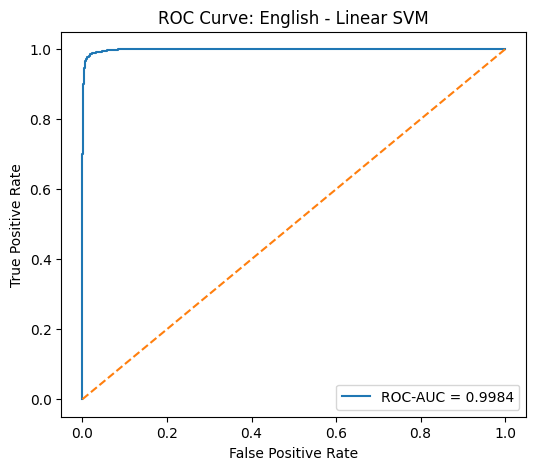

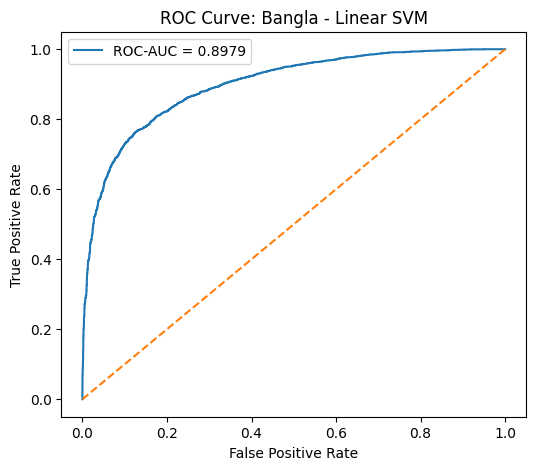

In [41]:
# Step 39: ROC Curve Function for Best Models

def get_model_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    elif hasattr(model, "decision_function"):
        return model.decision_function(X)
    else:
        return None


def plot_roc_for_model(model, X_test, y_test, language, model_name):
    scores = get_model_scores(model, X_test)
    if scores is None:
        print(f"ROC curve not available for {language} - {model_name}")
        return

    fpr, tpr, _ = roc_curve(y_test, scores)
    auc_value = roc_auc_score(y_test, scores)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"ROC-AUC = {auc_value:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(f"ROC Curve: {language} - {model_name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

plot_roc_for_model(english_trained_models[best_english_model_name], X_eng_test_tfidf, y_eng_test, "English", best_english_model_name)
plot_roc_for_model(bangla_trained_models[best_bangla_model_name], X_ban_test_tfidf, y_ban_test, "Bangla", best_bangla_model_name)


## Correct Prediction Examples

This section displays correctly predicted examples for each algorithm. Both numeric labels and readable class meanings are shown.


In [42]:
# Step 40: Correct Prediction Examples for Each Algorithm

def show_balanced_correct_predictions(X_test_text, y_test, predictions_dict, language, label_map, n_per_model=5):
    print("=" * 100)
    print(f"Balanced Correct Prediction Examples for {language}")
    print("=" * 100)

    for model_name, y_pred in predictions_dict.items():
        prediction_df = pd.DataFrame({
            "Text": X_test_text.values,
            "Actual Label": y_test.values,
            "Predicted Label": y_pred
        })

        prediction_df = prediction_df[prediction_df["Actual Label"] == prediction_df["Predicted Label"]].copy()
        prediction_df["Actual Output"] = prediction_df["Actual Label"].map(label_map)
        prediction_df["Predicted Output"] = prediction_df["Predicted Label"].map(label_map)

        selected_examples = []
        for label_value in sorted(prediction_df["Actual Label"].unique()):
            class_examples = prediction_df[prediction_df["Actual Label"] == label_value].head(max(1, n_per_model // 2))
            selected_examples.append(class_examples)

        if selected_examples:
            selected_df = pd.concat(selected_examples).head(n_per_model)
        else:
            selected_df = prediction_df.head(n_per_model)

        print(f"\nModel: {model_name}")
        display(selected_df[["Text", "Actual Label", "Actual Output", "Predicted Label", "Predicted Output"]])

show_balanced_correct_predictions(X_eng_test, y_eng_test, english_test_predictions, "English", LABEL_MAP, n_per_model=5)
show_balanced_correct_predictions(X_ban_test, y_ban_test, bangla_test_predictions, "Bangla", LABEL_MAP, n_per_model=5)


Balanced Correct Prediction Examples for English

Model: Logistic Regression


,Text,Actual Label,Actual Output,Predicted Label,Predicted Output
3,watch chri cuomo shred kellyann conway hypocrit defend trump payforplay scheme charit foundat offer access public of...,0,Fake News,0,Fake News
8,gop implod california pass bill make congress censur trump racism detail month ago donald trump shock countri respon...,0,Fake News,0,Fake News
0,kerry tells capitol hill critics of iran nuclear deal to hold their fire until final deal secretary of state john ke...,1,Real News,1,Real News
1,us offici work restor public trust polic attorney gener us attorney gener loretta lynch monday strongli condemn week...,1,Real News,1,Real News



Model: Naive Bayes


,Text,Actual Label,Actual Output,Predicted Label,Predicted Output
3,watch chri cuomo shred kellyann conway hypocrit defend trump payforplay scheme charit foundat offer access public of...,0,Fake News,0,Fake News
8,gop implod california pass bill make congress censur trump racism detail month ago donald trump shock countri respon...,0,Fake News,0,Fake News
0,kerry tells capitol hill critics of iran nuclear deal to hold their fire until final deal secretary of state john ke...,1,Real News,1,Real News
2,sanction silver line russian chees produc istra russia russia ban import foodstuff west may caus headach european fa...,1,Real News,1,Real News



Model: Linear SVM


...

,Text,Actual Label,Actual Output,Predicted Label,Predicted Output
1,হোয়াইট হাউসে সাহায্যের সংখ্যা ল্যাভিশ মিশেল ওবামার তুলনায় অনেক কমে গেছে। । মেলানিয়া ট্রাম্প প্রথম মহিলা হিসাবে আর...,0,Fake News,0,Fake News
4,"৯ বছরের আরেকটি সন্তান আছে, স্বীকার করলেন যশ অভিনেত্রী নুসরাত জাহানের পুত্রসন্তানের বাবা যশ দাশগুপ্ত। কিন্তু সম্প্রতি...",0,Fake News,0,Fake News
2,"৪৭ বছর ধরে ‘নাগরিকত্বহীন’ জীবন ছকিনার ﻿﻿জন্ম বাংলাদেশে, বেড়ে ওঠাও এ দেশের মাটিতে তবুও তার নেই জাতীয় পরিচয়পত্র। স্...",1,Real News,1,Real News
3,এমবিবিএস ভর্তি পরীক্ষা শুক্রবার ঢাকা: রাজধানীসহ সারাদেশে একযোগে এমবিবিএস প্রথম বর্ষ ভর্তি পরীক্ষা শুক্রবার (৫ অক্টোব...,1,Real News,1,Real News



Model: Linear SVM


,Text,Actual Label,Actual Output,Predicted Label,Predicted Output
0,"মায়ের কোলে ১০ দিন বয়সী নবজাতক আয়েশা সিদ্দিকা কা’ন্না করছে, আবার হাসছে মায়ের কোলে ১০ দিন বয়সী নবজাতক আয়েশা সিদ্...",0,Fake News,0,Fake News
1,হোয়াইট হাউসে সাহায্যের সংখ্যা ল্যাভিশ মিশেল ওবামার তুলনায় অনেক কমে গেছে। । মেলানিয়া ট্রাম্প প্রথম মহিলা হিসাবে আর...,0,Fake News,0,Fake News
2,"৪৭ বছর ধরে ‘নাগরিকত্বহীন’ জীবন ছকিনার ﻿﻿জন্ম বাংলাদেশে, বেড়ে ওঠাও এ দেশের মাটিতে তবুও তার নেই জাতীয় পরিচয়পত্র। স্...",1,Real News,1,Real News
3,এমবিবিএস ভর্তি পরীক্ষা শুক্রবার ঢাকা: রাজধানীসহ সারাদেশে একযোগে এমবিবিএস প্রথম বর্ষ ভর্তি পরীক্ষা শুক্রবার (৫ অক্টোব...,1,Real News,1,Real News



Model: Random Forest


,Text,Actual Label,Actual Output,Predicted Label,Predicted Output
1,হোয়াইট হাউসে সাহায্যের সংখ্যা ল্যাভিশ মিশেল ওবামার তুলনায় অনেক কমে গেছে। । মেলানিয়া ট্রাম্প প্রথম মহিলা হিসাবে আর...,0,Fake News,0,Fake News
4,"৯ বছরের আরেকটি সন্তান আছে, স্বীকার করলেন যশ অভিনেত্রী নুসরাত জাহানের পুত্রসন্তানের বাবা যশ দাশগুপ্ত। কিন্তু সম্প্রতি...",0,Fake News,0,Fake News
2,"৪৭ বছর ধরে ‘নাগরিকত্বহীন’ জীবন ছকিনার ﻿﻿জন্ম বাংলাদেশে, বেড়ে ওঠাও এ দেশের মাটিতে তবুও তার নেই জাতীয় পরিচয়পত্র। স্...",1,Real News,1,Real News
3,এমবিবিএস ভর্তি পরীক্ষা শুক্রবার ঢাকা: রাজধানীসহ সারাদেশে একযোগে এমবিবিএস প্রথম বর্ষ ভর্তি পরীক্ষা শুক্রবার (৫ অক্টোব...,1,Real News,1,Real News


## Statistical Significance Testing

McNemar's test is used to compare whether the difference between two classifiers is statistically meaningful on the same test set. It compares where two models agree and disagree on identical test samples.


In [43]:
# Step 41: Statistical Significance Test Using McNemar's Test

from statsmodels.stats.contingency_tables import mcnemar

def run_mcnemar_test(y_true, pred_a, pred_b, model_a_name, model_b_name, language):
    y_true_values = np.array(y_true)
    pred_a = np.array(pred_a)
    pred_b = np.array(pred_b)

    correct_a = pred_a == y_true_values
    correct_b = pred_b == y_true_values

    both_correct = ((correct_a == True) & (correct_b == True)).sum()
    a_correct_b_wrong = ((correct_a == True) & (correct_b == False)).sum()
    a_wrong_b_correct = ((correct_a == False) & (correct_b == True)).sum()
    both_wrong = ((correct_a == False) & (correct_b == False)).sum()

    table = [
        [int(both_correct), int(a_correct_b_wrong)],
        [int(a_wrong_b_correct), int(both_wrong)]
    ]

    result = mcnemar(table, exact=False, correction=True)

    print(f"{language}: {model_a_name} vs {model_b_name}")
    print("Contingency Table:", table)
    print("McNemar Statistic:", round(result.statistic, 4))
    print("p-value:", f"{result.pvalue:.4e}")

    if result.pvalue < 0.05:
        print("Interpretation: The difference is statistically significant.\n")
    else:
        print("Interpretation: The difference is not statistically significant.\n")


def get_best_and_second_best_model(final_results_df, language):
    language_results = final_results_df[
        final_results_df["Language"] == language
    ].sort_values(by="F1-score", ascending=False)

    best_model = language_results.iloc[0]["Model"]
    second_best_model = language_results.iloc[1]["Model"]

    return best_model, second_best_model


# English: compare best model with second-best model
english_best_model, english_second_best_model = get_best_and_second_best_model(
    final_results_df,
    "English"
)

run_mcnemar_test(
    y_true=y_eng_test,
    pred_a=english_test_predictions[english_best_model],
    pred_b=english_test_predictions[english_second_best_model],
    model_a_name=english_best_model,
    model_b_name=english_second_best_model,
    language="English"
)


# Bangla: compare best model with second-best model
bangla_best_model, bangla_second_best_model = get_best_and_second_best_model(
    final_results_df,
    "Bangla"
)

run_mcnemar_test(
    y_true=y_ban_test,
    pred_a=bangla_test_predictions[bangla_best_model],
    pred_b=bangla_test_predictions[bangla_second_best_model],
    model_a_name=bangla_best_model,
    model_b_name=bangla_second_best_model,
    language="Bangla"
)

English: Linear SVM vs Logistic Regression
Contingency Table: [[7789, 81], [22, 112]]
McNemar Statistic: 32.6602
p-value: 1.0976e-08
Interpretation: The difference is statistically significant.

Bangla: Linear SVM vs Logistic Regression
Contingency Table: [[6481, 56], [38, 1441]]
McNemar Statistic: 3.0745
p-value: 7.9531e-02
Interpretation: The difference is not statistically significant.



## Pairwise Statistical Comparison

To further examine whether the best-performing classifier differs significantly from other classical machine learning models, pairwise McNemar tests were conducted. Linear SVM was compared against Logistic Regression, Naive Bayes, and Random Forest using the same test samples. This analysis helps determine whether observed performance differences are statistically meaningful beyond numerical metric differences.

Because multiple pairwise comparisons are performed, both raw p-values and Bonferroni-adjusted p-values are reported.

In [44]:
# Step 41A: Pairwise McNemar Test for Linear SVM Against Other Models

from statsmodels.stats.contingency_tables import mcnemar

def pairwise_mcnemar_table(y_true, predictions_dict, reference_model, language):
    """
    Compare one reference model against all other models using McNemar's test.
    Reports raw p-value and Bonferroni-adjusted p-value.
    """
    results = []

    y_true_values = np.array(y_true)
    reference_pred = np.array(predictions_dict[reference_model])

    comparison_models = [
        model_name for model_name in predictions_dict.keys()
        if model_name != reference_model
    ]

    number_of_comparisons = len(comparison_models)

    for comparison_model in comparison_models:
        comparison_pred = np.array(predictions_dict[comparison_model])

        reference_correct = reference_pred == y_true_values
        comparison_correct = comparison_pred == y_true_values

        both_correct = ((reference_correct == True) & (comparison_correct == True)).sum()
        reference_correct_comparison_wrong = ((reference_correct == True) & (comparison_correct == False)).sum()
        reference_wrong_comparison_correct = ((reference_correct == False) & (comparison_correct == True)).sum()
        both_wrong = ((reference_correct == False) & (comparison_correct == False)).sum()

        contingency_table = [
            [int(both_correct), int(reference_correct_comparison_wrong)],
            [int(reference_wrong_comparison_correct), int(both_wrong)]
        ]

        test_result = mcnemar(
            contingency_table,
            exact=False,
            correction=True
        )

        raw_p_value = test_result.pvalue
        bonferroni_adjusted_p_value = min(raw_p_value * number_of_comparisons, 1.0)

        if bonferroni_adjusted_p_value < 0.05:
            interpretation = "Significant after Bonferroni correction"
        elif raw_p_value < 0.05:
            interpretation = "Significant before correction only"
        else:
            interpretation = "Not statistically significant"

        results.append({
            "Language": language,
            "Reference Model": reference_model,
            "Comparison Model": comparison_model,
            "Both Correct": int(both_correct),
            "Reference Correct / Comparison Wrong": int(reference_correct_comparison_wrong),
            "Reference Wrong / Comparison Correct": int(reference_wrong_comparison_correct),
            "Both Wrong": int(both_wrong),
            "McNemar Statistic": round(test_result.statistic, 4),
            "Raw p-value": round(raw_p_value, 6),
            "Bonferroni-adjusted p-value": round(bonferroni_adjusted_p_value, 6),
            "Interpretation": interpretation
        })

    return pd.DataFrame(results)


# English pairwise comparison: Linear SVM vs other models
english_pairwise_mcnemar = pairwise_mcnemar_table(
    y_true=y_eng_test,
    predictions_dict=english_test_predictions,
    reference_model="Linear SVM",
    language="English"
)

# Bangla pairwise comparison: Linear SVM vs other models
bangla_pairwise_mcnemar = pairwise_mcnemar_table(
    y_true=y_ban_test,
    predictions_dict=bangla_test_predictions,
    reference_model="Linear SVM",
    language="Bangla"
)

# Combine English and Bangla results
pairwise_mcnemar_results = pd.concat(
    [english_pairwise_mcnemar, bangla_pairwise_mcnemar],
    ignore_index=True
)

display(pairwise_mcnemar_results)

,Language,Reference Model,Comparison Model,Both Correct,Reference Correct / Comparison Wrong,Reference Wrong / Comparison Correct,Both Wrong,McNemar Statistic,Raw p-value,Bonferroni-adjusted p-value,Interpretation
0,English,Linear SVM,Logistic Regression,7789,81,22,112,32.6602,0.000000,0.000000,Significant after Bonferroni correction
1,English,Linear SVM,Naive Bayes,7457,413,41,93,303.1740,0.000000,0.000000,Significant after Bonferroni correction
2,English,Linear SVM,Random Forest,7672,198,48,86,90.2480,0.000000,0.000000,Significant after Bonferroni correction
3,Bangla,Linear SVM,Logistic Regression,6481,56,38,1441,3.0745,0.079531,0.238592,Not statistically significant
4,Bangla,Linear SVM,Naive Bayes,5666,871,407,1072,167.7379,0.000000,0.000000,Significant after Bonferroni correction
5,Bangla,Linear SVM,Random Forest,5960,577,391,1088,35.3564,0.000000,0.000000,Significant after Bonferroni correction


## Error Analysis

Error analysis helps explain model limitations beyond numerical scores. Misclassified fake and real news examples are reviewed to identify possible causes such as ambiguous vocabulary, short text, overlapping political terms, and cases requiring external factual knowledge.


In [45]:
# Step 42: Error Analysis Function

def show_misclassified_examples(X_test_text, y_test, y_pred, language, model_name, n=10):
    error_df = pd.DataFrame({
        "Text": X_test_text.values,
        "Actual Label": y_test.values,
        "Predicted Label": y_pred
    })

    error_df = error_df[error_df["Actual Label"] != error_df["Predicted Label"]].copy()
    error_df["Actual Meaning"] = error_df["Actual Label"].map(LABEL_MAP)
    error_df["Predicted Meaning"] = error_df["Predicted Label"].map(LABEL_MAP)

    print(f"Misclassified Examples for {language} - {model_name}")
    print("Number of Misclassified Examples:", error_df.shape[0])
    print(f"\nShowing first {n} misclassified examples:")

    display(error_df.head(n))
    return error_df

english_error_df = show_misclassified_examples(
    X_test_text=X_eng_test,
    y_test=y_eng_test,
    y_pred=english_best_predictions,
    language="English",
    model_name=best_english_model_name,
    n=10
)

bangla_error_df = show_misclassified_examples(
    X_test_text=X_ban_test,
    y_test=y_ban_test,
    y_pred=bangla_best_predictions,
    language="Bangla",
    model_name=best_bangla_model_name,
    n=10
)


Misclassified Examples for English - Linear SVM
Number of Misclassified Examples: 134

Showing first 10 misclassified examples:


,Text,Actual Label,Predicted Label,Actual Meaning,Predicted Meaning
101,kasich call activ step strengthen usisrael tie presidenti candid john kasich call monday activ step strengthen tie u...,1,0,Real News,Fake News
171,trump humili forc sign russia sanction bill limit power amateur presid donald trump sign forc sign bill today punish...,0,1,Fake News,Real News
235,hillari clinton happen fend oreilli bestsel happen hillari clinton memoir unsuccess bid win us presidenti elect top ...,1,0,Real News,Fake News
322,trump new hire scaramucci make conciliatori debut media presid donald trump refer media fake news want staff use con...,1,0,Real News,Fake News
459,an obama boom according to a transition pool report the media personalities are as follows nbc news president debora...,1,0,Real News,Fake News
480,us apolog human right violat un review countri wors human right violat obama apolog tour greatest countri world cont...,0,1,Fake News,Real News
662,a nuclear deal has been reached but iran must free jason rezaian just as negotiators were completing an agreement on...,1,0,Real News,Fake News
725,there s no case here clinton defiant amid email probe the race for the white house has become even more uncertain as...,1,0,Real News,Fake News
756,visit cartagena pope honor slave slave role model bogotacartagena colombia pope franci sunday pay homag social justi...,1,0,Real News,Fake News
761,donald trump is going to win this is why hillary clinton can t defeat what trump represents the trump alliance desir...,1,0,Real News,Fake News


Misclassified Examples for Bangla - Linear SVM
Number of Misclassified Examples: 1479

Showing first 10 misclassified examples:


,Text,Actual Label,Predicted Label,Actual Meaning,Predicted Meaning
9,"পঞ্চম ও অষ্টম শ্রেণীর শিক্ষার্থীদের জন্য আসলো দুঃ; সংবাদ! ২৪ মে প্রকাশিত দৈনিক সংবাদের প্রতিবেদন থেকে জানা গেছে, পঞ্...",0,1,Fake News,Real News
14,"ষড়যন্ত্রের ঐক্য কোন ফল দেবে না: মেনন সমাজকল্যাণ মন্ত্রী রাশেদ খান মেনন বলেছেন, ড. কামাল হোসেন ও বদরুদ্দোজা চৌধুরীর ...",0,1,Fake News,Real News
16,ধর্ম হাতিয়ার হিসাব জামা গ্রাম আওয়ামীলীগ সরকার দেশ উন্নত করেছে। উন্নত ধারা অব্যাহত রাখতে প্রধানমন্ত্রী শেখ হাসিনা ন...,0,1,Fake News,Real News
17,"ক্লোনিং-এর নামে প্রতারণা, সতর্ক থাকুন ফেসবুকে ক্লোনিংয়ের নামে ফেসবুক ব্যবহারকারীরা প্রতারিত হচ্ছেন বলে অভিযোগ পাওয়...",1,0,Real News,Fake News
24,না’য়ি’কা প্র’ভাকে জী’বনস’ঙ্গী হিসেবে পেতে চাইলে পা’ত্রের থা’কতে হবে দু’টি যো’গ্যতা দীর্ঘ সময় ধরেই অভিনয় অ; ঙ্গনে ...,0,1,Fake News,Real News
30,৫০ কোটি টাকায় নির্মিত হবে মাসুদ রানা সিনেমা ‘মাসুদ রানা’ গোয়েন্দা গল্প নিয়ে বাংলাদেশে বেশ বড় বাজেটের সিনেমা নির্...,1,0,Real News,Fake News
34,তাসকিন একাই তুলে নিলেন তিন উইকেট লঙ্কানদের বি; পক্ষে সিরিজের শেষ ওয়ানডেতে বল হাতে জ্ব; লে উঠেছেন তাসকিন আহমেদ। এ পর...,0,1,Fake News,Real News
38,পাকিস্তান বৈঠক বাতিল করল নয়া সেপ্টেম্বর: আলোচ্য ইসলাম নিউইয়র্ জাতিসংঘ অধিবেশনে ফাঁক পাকিস্তান পররাষ্ট্র এক বৈঠক হও...,1,0,Real News,Fake News
39,"লাইভে ড্রেস ছাড়া মডেল, ভাইরাল ভিডিও 2 hours ago 2 hours ago 3 hours ago সুন্দরী বেছে নেওয়ার প্রতিযোগিতার সরাসরি সম...",1,0,Real News,Fake News
42,সরকারী খাস জমি চিহ্নিত করার সময় দা-রামদা দিয়ে দখলদারদের হামলা! সুনামগঞ্জে সরকারের খাস জমি চিহ্নিত করার সময় দখলদার...,0,1,Fake News,Real News


In [46]:
# Step 43: Error Type Summary

def error_type_summary(error_df, language):
    if error_df.empty:
        return pd.DataFrame({"Language": [language], "Error Type": ["No errors"], "Count": [0]})

    error_df = error_df.copy()
    error_df["Error Type"] = error_df.apply(
        lambda row: "Fake predicted as Real" if row["Actual Label"] == 0 and row["Predicted Label"] == 1 else "Real predicted as Fake",
        axis=1
    )

    summary = error_df["Error Type"].value_counts().reset_index()
    summary.columns = ["Error Type", "Count"]
    summary.insert(0, "Language", language)
    return summary

error_summary_table = pd.concat([
    error_type_summary(english_error_df, "English"),
    error_type_summary(bangla_error_df, "Bangla")
], ignore_index=True)

display(error_summary_table)


,Language,Error Type,Count
0,English,Fake predicted as Real,80
1,English,Real predicted as Fake,54
2,Bangla,Real predicted as Fake,793
3,Bangla,Fake predicted as Real,686


## Error Analysis Discussion

The misclassified examples provide insight into the limitations of the trained models beyond numerical performance scores. Some fake news samples may be predicted as real when they follow a formal or professional news-writing style, while some real news samples may be misclassified when they contain emotional, political, or sensational vocabulary.

For English text, classification errors may occur when fake and real articles share similar topics, vocabulary, or writing structure. For Bangla text, errors may also be influenced by spelling variation, morphology, informal wording, named-entity variation, and overlapping political or social terms. These findings suggest that TF-IDF-based classical machine learning models are useful baseline systems, but they may not fully capture deeper contextual and semantic meaning.

## Bangla Language Challenges

Bangla fake news detection presents several language-specific challenges. Bangla is a comparatively low-resource language, and fake news texts may contain spelling variation, informal writing, named-entity variation, code-mixed expressions, and morphology-rich word forms. These characteristics can make TF-IDF-based feature representation more challenging than English.

In addition, some Bangla fake news may use political, social, or emotional vocabulary that overlaps with real news articles. Therefore, classification errors may occur when fake and real news share similar topics or writing styles. This highlights the importance of error analysis and careful interpretation of model predictions.

## TF-IDF Feature Interpretation

For linear models such as Logistic Regression and Linear SVM, feature weights can be inspected to identify n-grams associated with each class. These features should be interpreted carefully as model-associated indicators, not absolute evidence of truth or falsehood.


In [47]:
# Step 44: Top TF-IDF Features for Logistic Regression

def show_top_logistic_features(model, vectorizer, language, top_n=20):
    if not hasattr(model, "coef_"):
        print(f"{language}: This model does not provide linear coefficients.")
        return None

    feature_names = np.array(vectorizer.get_feature_names_out())
    coefs = model.coef_[0]

    top_real_idx = np.argsort(coefs)[-top_n:][::-1]
    top_fake_idx = np.argsort(coefs)[:top_n]

    feature_df = pd.DataFrame({
        "Language": [language] * (top_n * 2),
        "Class Association": ["Real News (1)"] * top_n + ["Fake News (0)"] * top_n,
        "Feature": list(feature_names[top_real_idx]) + list(feature_names[top_fake_idx]),
        "Coefficient": list(coefs[top_real_idx]) + list(coefs[top_fake_idx])
    })

    display(feature_df)
    return feature_df

english_lr_model = english_trained_models["Logistic Regression"]
bangla_lr_model = bangla_trained_models["Logistic Regression"]

english_top_features = show_top_logistic_features(english_lr_model, english_tfidf, "English", top_n=20)
bangla_top_features = show_top_logistic_features(bangla_lr_model, bangla_tfidf, "Bangla", top_n=20)


,Language,Class Association,Feature,Coefficient
0,English,Real News (1),said,12.695113
1,English,Real News (1),presid donald,5.427172
2,English,Real News (1),tuesday,5.256094
3,English,Real News (1),wednesday,5.068530
4,English,Real News (1),thursday,4.947095
5,English,Real News (1),us presid,4.896433
6,English,Real News (1),us,4.854840
7,English,Real News (1),friday,4.578062
8,English,Real News (1),monday,4.421050
9,English,Real News (1),minist,3.710276


,Language,Class Association,Feature,Coefficient
0,Bangla,Real News (1),২০১৮,8.969513
1,Bangla,Real News (1),অক বর,7.174918
2,Bangla,Real News (1),বর ২০১৮,6.008246
3,Bangla,Real News (1),অক,5.761696
4,Bangla,Real News (1),ইমস,5.549111
5,Bangla,Real News (1),আইএম,5.360411
6,Bangla,Real News (1),এমএস,4.679301
7,Bangla,Real News (1),এশ,4.503767
8,Bangla,Real News (1),আরট এনএন,3.820066
9,Bangla,Real News (1),এশ ইন,3.373638


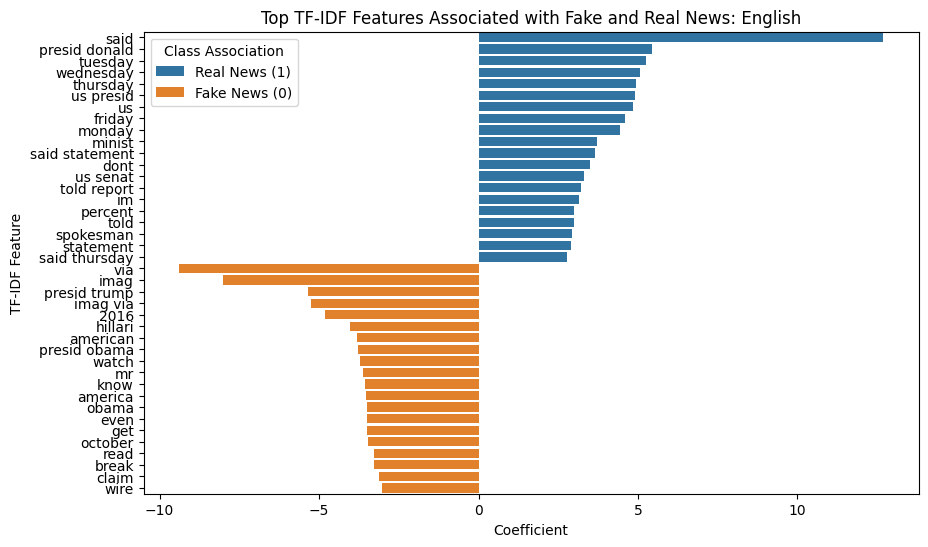

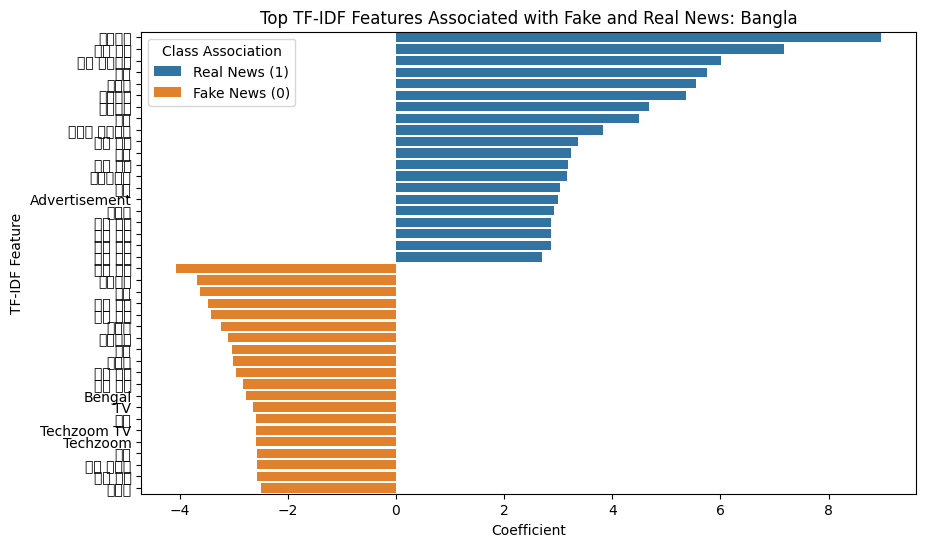

In [48]:
# Step 45: Visualize Top Logistic Regression Features

def plot_top_features(feature_df, language):
    if feature_df is None:
        return

    plt.figure(figsize=(10, 6))
    sns.barplot(data=feature_df, x="Coefficient", y="Feature", hue="Class Association")
    plt.title(f"Top TF-IDF Features Associated with Fake and Real News: {language}")
    plt.xlabel("Coefficient")
    plt.ylabel("TF-IDF Feature")
    plt.show()

plot_top_features(english_top_features, "English")
plot_top_features(bangla_top_features, "Bangla")


## TF-IDF Ablation Study

An ablation study was conducted to examine how different TF-IDF configurations affect fake news detection performance. The purpose of this experiment is to evaluate whether unigram features alone are sufficient or whether adding bigram features improves model performance.

To keep the ablation focused and computationally efficient, Linear SVM was used as the classifier because it showed strong performance in the main experiments. The ablation was performed on the validation set only, while the test set remained reserved for final model reporting.

In [49]:
# Step 45A: TF-IDF Ablation Study Using Linear SVM

def run_tfidf_ablation(
    X_train,
    y_train,
    X_val,
    y_val,
    language,
    best_c,
    lowercase_setting
):
    """
    Runs TF-IDF ablation experiments using Linear SVM.
    The validation set is used for comparison.
    The test set is not used in this ablation to avoid test-set overuse.
    """

    ablation_configs = [{
            "Configuration": "Unigram, 10k features",
            "ngram_range": (1, 1),
            "max_features": 10000
        },
        {
            "Configuration": "Unigram, 20k features",
            "ngram_range": (1, 1),
            "max_features": 20000
        },
        {
            "Configuration": "Unigram + Bigram, 10k features",
            "ngram_range": (1, 2),
            "max_features": 10000
        },
        {
            "Configuration": "Unigram + Bigram, 20k features",
            "ngram_range": (1, 2),
            "max_features": 20000
        }
    ]

    ablation_results = []
    for config in ablation_configs:
        vectorizer = TfidfVectorizer(
            max_features=config["max_features"],
            ngram_range=config["ngram_range"],
            min_df=2,
            max_df=0.95,
            sublinear_tf=True,
            lowercase=lowercase_setting
        )

        X_train_tfidf_ablation = vectorizer.fit_transform(X_train)
        X_val_tfidf_ablation = vectorizer.transform(X_val)
        model = LinearSVC(
            C=best_c,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            max_iter=10000
        )

        model.fit(X_train_tfidf_ablation, y_train)
        y_val_pred = model.predict(X_val_tfidf_ablation)
        ablation_results.append({
            "Language": language,
            "Configuration": config["Configuration"],
            "ngram_range": str(config["ngram_range"]),
            "max_features": config["max_features"],
            "Validation Accuracy": accuracy_score(y_val, y_val_pred),
            "Validation Precision": precision_score(y_val, y_val_pred, average="weighted", zero_division=0),
            "Validation Recall": recall_score(y_val, y_val_pred, average="weighted", zero_division=0),
            "Validation F1-score": f1_score(y_val, y_val_pred, average="weighted", zero_division=0),
            "Validation Macro-F1": f1_score(y_val, y_val_pred, average="macro", zero_division=0)
        })
    return pd.DataFrame(ablation_results)

# English TF-IDF ablation
english_ablation_df = run_tfidf_ablation(
    X_train=X_eng_train,
    y_train=y_eng_train,
    X_val=X_eng_val,
    y_val=y_eng_val,
    language="English",
    best_c=best_c_english,
    lowercase_setting=True
)
# Bangla TF-IDF ablation
bangla_ablation_df = run_tfidf_ablation(
    X_train=X_ban_train,
    y_train=y_ban_train,
    X_val=X_ban_val,
    y_val=y_ban_val,
    language="Bangla",
    best_c=best_c_bangla,
    lowercase_setting=False
)
# Combine ablation results
ablation_results_df = pd.concat(
    [english_ablation_df, bangla_ablation_df],
    ignore_index=True
)

ablation_results_df = ablation_results_df.round(4)
display(ablation_results_df)

,Language,Configuration,ngram_range,max_features,Validation Accuracy,Validation Precision,Validation Recall,Validation F1-score,Validation Macro-F1
0,English,"Unigram, 10k features","(1, 1)",10000,0.9760,0.9760,0.9760,0.9760,0.9760
1,English,"Unigram, 20k features","(1, 1)",20000,0.9778,0.9778,0.9778,0.9778,0.9778
2,English,"Unigram + Bigram, 10k features","(1, 2)",10000,0.9800,0.9800,0.9800,0.9800,0.9800
3,English,"Unigram + Bigram, 20k features","(1, 2)",20000,0.9818,0.9818,0.9818,0.9818,0.9818
4,Bangla,"Unigram, 10k features","(1, 1)",10000,0.8006,0.8007,0.8006,0.8006,0.8006
5,Bangla,"Unigram, 20k features","(1, 1)",20000,0.8006,0.8007,0.8006,0.8006,0.8006
6,Bangla,"Unigram + Bigram, 10k features","(1, 2)",10000,0.8161,0.8162,0.8161,0.8161,0.8161
7,Bangla,"Unigram + Bigram, 20k features","(1, 2)",20000,0.8221,0.8222,0.8221,0.8221,0.8221


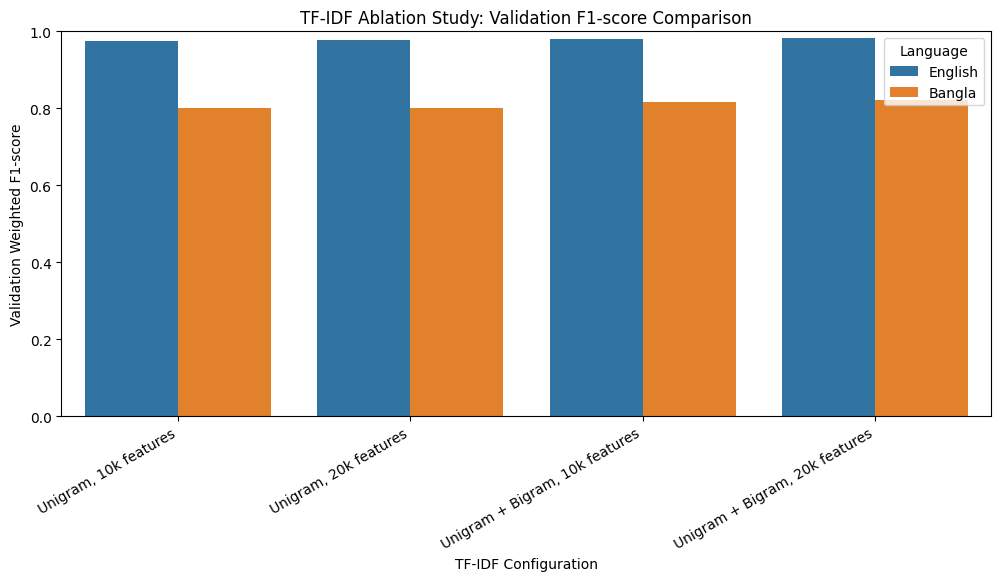

In [50]:
# Step 45B: Visualize TF-IDF Ablation Results

plt.figure(figsize=(12, 5))
sns.barplot(
    data=ablation_results_df,
    x="Configuration",
    y="Validation F1-score",
    hue="Language"
)

plt.title("TF-IDF Ablation Study: Validation F1-score Comparison")
plt.xlabel("TF-IDF Configuration")
plt.ylabel("Validation Weighted F1-score")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.legend(title="Language")
plt.show()

## Ablation Study Interpretation

The ablation results compare different TF-IDF configurations using Linear SVM on the validation set. If unigram + bigram features perform better than unigram-only features, it suggests that local word-pair patterns provide useful information for fake news detection. If increasing the number of TF-IDF features improves performance, it suggests that a larger vocabulary helps the classifier capture more discriminative terms.

The final test set was not used during the ablation process. This helps preserve the test set for unbiased final performance reporting.

## Bangla vs English Comparative Analysis

The final comparison examines whether model performance differs between Bangla and English. Differences may be related to dataset characteristics, language resource availability, preprocessing, morphology, vocabulary variation, and source distribution.


In [51]:
# Step 46: Best Model Comparison Table

best_model_comparison = pd.DataFrame({
    "Language": ["English", "Bangla"],
    "Best Model": [best_english_test["Model"], best_bangla_test["Model"]],
    "Accuracy": [best_english_test["Accuracy"], best_bangla_test["Accuracy"]],
    "Precision": [best_english_test["Precision"], best_bangla_test["Precision"]],
    "Recall": [best_english_test["Recall"], best_bangla_test["Recall"]],
    "F1-score": [best_english_test["F1-score"], best_bangla_test["F1-score"]],
    "Macro-F1": [best_english_test["Macro-F1"], best_bangla_test["Macro-F1"]],
    "ROC-AUC": [best_english_test["ROC-AUC"], best_bangla_test["ROC-AUC"]]
})

best_model_comparison = best_model_comparison.round(4)
display(best_model_comparison)


,Language,Best Model,Accuracy,Precision,Recall,F1-score,Macro-F1,ROC-AUC
0,English,Linear SVM,0.9833,0.9833,0.9833,0.9833,0.9833,0.9984
1,Bangla,Linear SVM,0.8155,0.8157,0.8155,0.8155,0.8155,0.8979


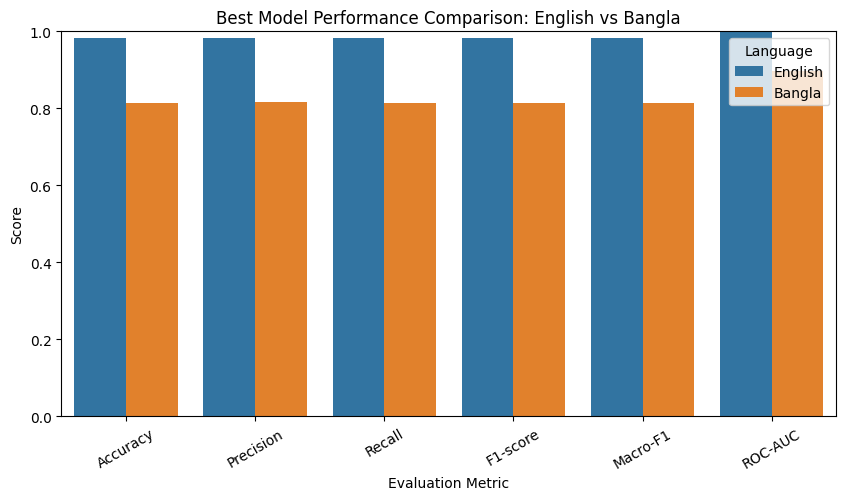

In [52]:
# Step 47: Final Comparative Bar Chart

comparison_melted = best_model_comparison.melt(
    id_vars=["Language", "Best Model"],
    value_vars=["Accuracy", "Precision", "Recall", "F1-score", "Macro-F1", "ROC-AUC"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_melted, x="Metric", y="Score", hue="Language")
plt.title("Best Model Performance Comparison: English vs Bangla")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.show()


## Performance Gap Discussion

The final results show a noticeable performance difference between English and Bangla fake news detection. English models achieved higher performance, which may be related to more standardized writing patterns, richer NLP resources, and more consistent vocabulary representation. In contrast, Bangla fake news detection is more challenging because Bangla text may contain spelling variation, informal expressions, morphology-rich word forms, named-entity variation, and topic overlap between fake and real news.

This performance gap suggests that TF-IDF-based classical machine learning models provide useful baseline performance but may not fully capture the deeper contextual and semantic features needed for more robust Bangla fake news detection.

## Future Work: Transformer-Based Models

This notebook focuses on traditional machine learning models using TF-IDF features. In future work, transformer-based models such as BanglaBERT, multilingual BERT, and XLM-RoBERTa can be implemented to compare contextual language models with traditional TF-IDF-based classifiers.

Transformer models may improve fake news detection performance because they can capture word meaning, sentence context, and semantic relationships more effectively than TF-IDF. This may be especially useful for Bangla fake news detection, where spelling variation, morphology, and contextual meaning play an important role.

Future research can also include larger datasets, external test sets, cross-lingual learning, ensemble methods, explainability analysis, and multimodal fake news detection using both text and images.

## Limitations

This study has several limitations. First, the models are based on TF-IDF features, which capture term frequency patterns but do not fully represent deeper semantic meaning, sentence context, or pragmatic intent. As a result, fake and real news articles with similar vocabulary or writing style may still be misclassified.

Second, although the datasets were cleaned, balanced, and checked for cross-split overlap, the results may still depend on the characteristics of the source datasets. Therefore, performance on unseen real-world news sources may differ from the reported test results.

Third, this notebook focuses on classical machine learning models and does not implement transformer-based models such as BanglaBERT, multilingual BERT, or XLM-RoBERTa. These models may provide stronger contextual representations, especially for Bangla text.

Finally, the study uses text-only fake news detection. Future research may include multimodal features such as images, metadata, source credibility, and user engagement patterns.

## Saving Result Tables

The result tables are saved as CSV files in the Kaggle working directory. These files can be downloaded from the notebook output section after running the notebook.


In [53]:
# Step 48: Save Result Tables

# Main performance result tables
validation_results_df.to_csv("validation_results.csv", index=False)
final_results_df.to_csv("final_test_results.csv", index=False)

# Final summary and comparison tables
summary_table.to_csv("final_summary_table.csv")
best_model_comparison.to_csv("best_model_comparison.csv", index=False)

# Hyperparameter tuning and cross-validation outputs
best_hyperparameters.to_csv("best_hyperparameters.csv", index=False)
cv_summary.to_csv("cross_validation_summary.csv", index=False)

# Confusion matrix and error analysis outputs
confusion_summary.to_csv("confusion_matrix_summary.csv", index=False)
error_summary_table.to_csv("error_summary_table.csv", index=False)

# Pairwise McNemar statistical comparison, if available
if "pairwise_mcnemar_results" in globals():
    pairwise_mcnemar_results.to_csv("pairwise_mcnemar_results.csv", index=False)

# TF-IDF feature interpretation outputs
if "english_top_features" in globals() and english_top_features is not None:
    english_top_features.to_csv("english_top_tfidf_features.csv", index=False)
if "bangla_top_features" in globals() and bangla_top_features is not None:
    bangla_top_features.to_csv("bangla_top_tfidf_features.csv", index=False)

# Misclassified example outputs
if "english_error_df" in globals():
    english_error_df.to_csv("english_error_analysis.csv", index=False)
if "bangla_error_df" in globals():
    bangla_error_df.to_csv("bangla_error_analysis.csv", index=False)

# Optional ablation output, if you add Step 45A later
if "ablation_results_df" in globals():
    ablation_results_df.to_csv("tfidf_ablation_results.csv", index=False)

print("All result tables saved successfully.")

All result tables saved successfully.


## Methodology Summary for Thesis Writing

The study used cleaned and quality-controlled datasets for Bangla and English fake news detection. Both datasets followed the same binary label mapping, where `0` represented fake news and `1` represented real news. The datasets were kept separate to preserve language-specific characteristics and to enable fair comparative analysis.

TF-IDF was used to convert textual news content into numerical features. The TF-IDF vectorizer was fitted only on the training set to avoid data leakage, while the validation and test sets were transformed using the training-fitted vectorizer. Unigram and bigram features were used to capture both individual terms and local word patterns.

Classical machine learning models, including Logistic Regression, Multinomial Naive Bayes, Linear Support Vector Machine, and Random Forest, were trained and evaluated. The validation set was used for model comparison and hyperparameter selection, while the test set was reserved for final performance reporting. Performance was measured using accuracy, precision, recall, F1-score, macro-F1, ROC-AUC, and confusion matrices.

Error analysis and TF-IDF feature interpretation were performed to better understand model behavior beyond numerical metrics. Misclassified samples were reviewed to identify possible sources of error, and top model-associated TF-IDF features were examined for interpretability.


## Notebook Conclusion

This notebook presented a comparative fake news detection study for English and Bangla text using TF-IDF features and classical machine learning models. Four traditional classifiers were evaluated: Logistic Regression, Multinomial Naive Bayes, Linear SVM, and Random Forest.

The datasets were prepared as cleaned, balanced, binary classification datasets with the label mapping 0 = Fake News and 1 = Real News. Separate train, validation, and test sets were used for both languages to support fair evaluation and avoid data leakage. TF-IDF unigram and bigram features were extracted separately for English and Bangla text.

The models were evaluated using accuracy, precision, recall, weighted F1-score, macro-F1, ROC-AUC, confusion matrices, cross-validation, and statistical significance testing. The final results show that classical machine learning models can provide strong baseline performance for bilingual fake news detection. English represents a comparatively high-resource language setting, while Bangla represents a lower-resource language setting with additional linguistic challenges such as spelling variation, morphology, informal writing, and limited NLP resources.

Overall, Linear SVM showed strong performance across both languages, while the comparative analysis highlighted differences between English and Bangla fake news detection. This notebook provides a complete experimental pipeline that can be extended in future work using transformer-based models, external test sets, explainability methods, and ablation studies.

In [54]:
# Step 49: Final Completion Message

print("Notebook execution completed successfully.")
print("Use the validation results for model selection and the test results for final reporting.")
print("Remember: 0 = Fake News, 1 = Real News for both English and Bangla datasets.")


Notebook execution completed successfully.
Use the validation results for model selection and the test results for final reporting.
Remember: 0 = Fake News, 1 = Real News for both English and Bangla datasets.
